In [7]:
# STEP 1 — Import libraries
import warnings
warnings.filterwarnings("ignore")
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42


In [8]:
# STEP 2 — Load the dataset
# The first name matches the GitHub repo structure; the second matches the uploaded file.
if os.path.exists("diabetes.csv"):
    DATA_PATH = "diabetes.csv"
elif os.path.exists("diabetes (1).csv"):
    DATA_PATH = "diabetes (1).csv"
else:
    raise FileNotFoundError(
        "Put diabetes.csv (or diabetes (1).csv) in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Loaded file:", DATA_PATH)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget values:")
print(sorted(df["Outcome"].unique()))


Loaded file: diabetes (1).csv
Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data types:


,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Missing values:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Duplicate rows: 0

Target values:
[np.int64(0), np.int64(1)]


In [9]:
# STEP 3 — Validate the target and check data quality
assert set(df["Outcome"].unique()).issubset({0, 1}), "Outcome must contain only 0 and 1."

print("Rows before cleaning:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(df_clean))
print("Duplicates after cleaning:", df_clean.duplicated().sum())
print("Total explicit missing values:", df_clean.isna().sum().sum())


Rows before cleaning: 768
Exact duplicate rows: 0
Rows after removing duplicates: 768
Duplicates after cleaning: 0
Total explicit missing values: 0


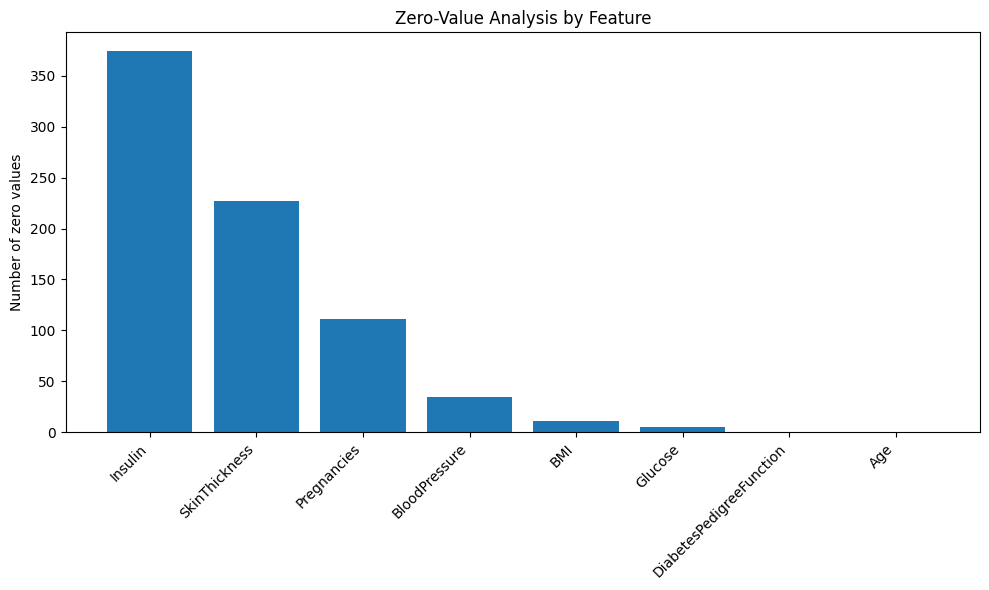

,zero_count
Insulin,374
SkinThickness,227
Pregnancies,111
BloodPressure,35
BMI,11
Glucose,5
DiabetesPedigreeFunction,0
Age,0


In [10]:
zero_check_cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

zero_counts = (df_clean[zero_check_cols] == 0).sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(zero_counts.index, zero_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of zero values")
plt.title("Zero-Value Analysis by Feature")
plt.tight_layout()
plt.show()

display(zero_counts.to_frame("zero_count"))


In [11]:
# STEP 5 — Replace placeholder zeros with NaN
zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_model = df_clean.copy()
df_model[zero_as_missing] = df_model[zero_as_missing].replace(0, np.nan)

print("Missing values after zero-value treatment:")
display(df_model.isna().sum().sort_values(ascending=False))

print("Total missing values after treatment:",
      int(df_model.isna().sum().sum()))


Missing values after zero-value treatment:


,0
Insulin,374
SkinThickness,227
BloodPressure,35
BMI,11
Glucose,5
Pregnancies,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Total missing values after treatment: 652


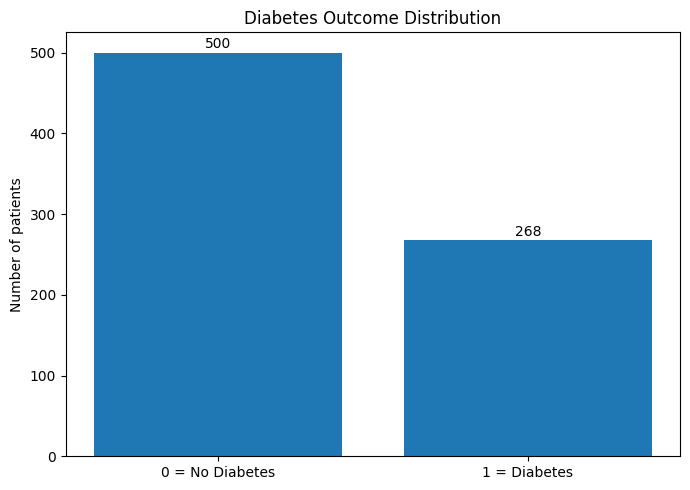

Target counts:


,count
Outcome,
0,500
1,268


Target percentages:


,proportion
Outcome,
0,65.1
1,34.9


In [12]:
# STEP 6 — Target distribution
target_counts = df_model["Outcome"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["0 = No Diabetes", "1 = Diabetes"], target_counts.values)
plt.ylabel("Number of patients")
plt.title("Diabetes Outcome Distribution")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + max(target_counts.values)*0.01, str(value),
             ha="center")

plt.tight_layout()
plt.show()

print("Target counts:")
display(target_counts)

print("Target percentages:")
display((df_model["Outcome"].value_counts(normalize=True).sort_index() * 100).round(2))


In [13]:
# STEP 7 — Descriptive statistics
display(df_model.describe().T)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
BloodPressure,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


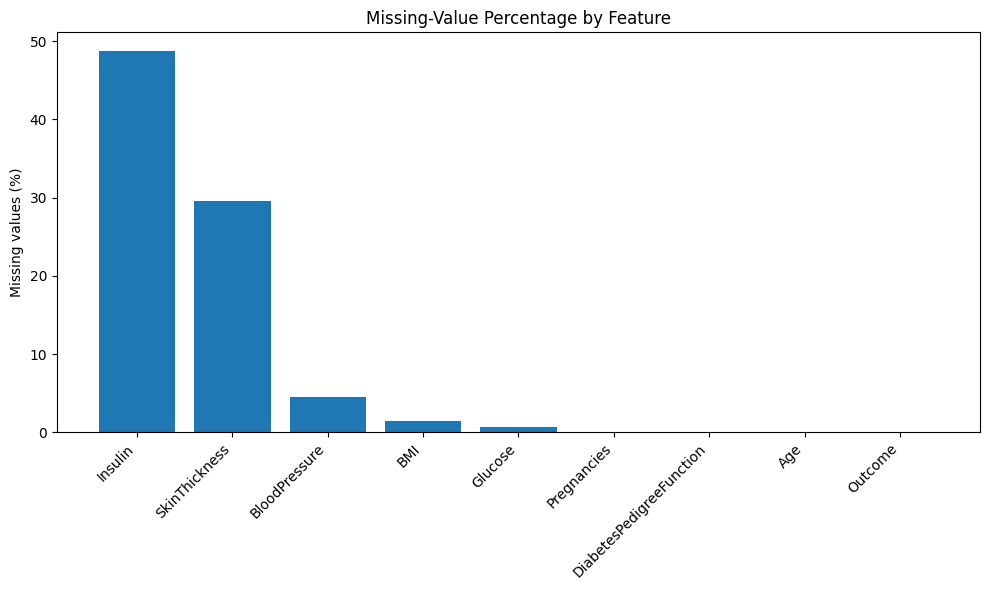

,missing_percentage
Insulin,48.697917
SkinThickness,29.557292
BloodPressure,4.557292
BMI,1.432292
Glucose,0.651042
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000
Age,0.000000
Outcome,0.000000


In [14]:
# STEP 8 — Missing-value percentage
missing_pct = (
    df_model.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(missing_pct.index, missing_pct.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing values (%)")
plt.title("Missing-Value Percentage by Feature")
plt.tight_layout()
plt.show()

display(missing_pct.to_frame("missing_percentage"))


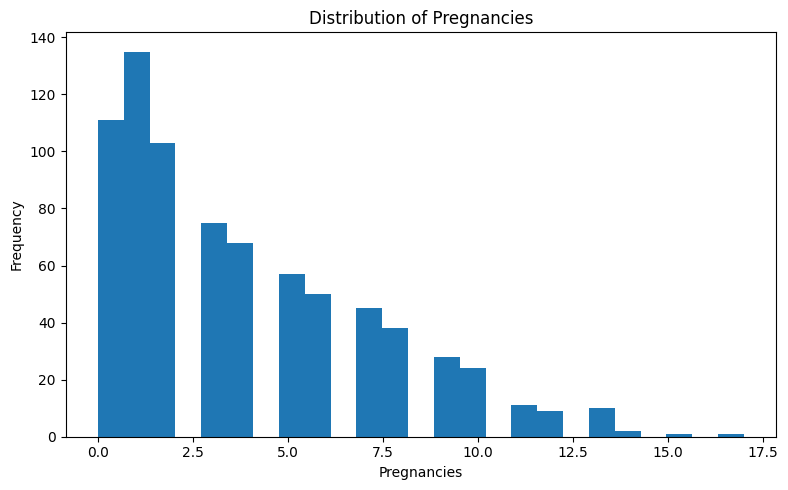

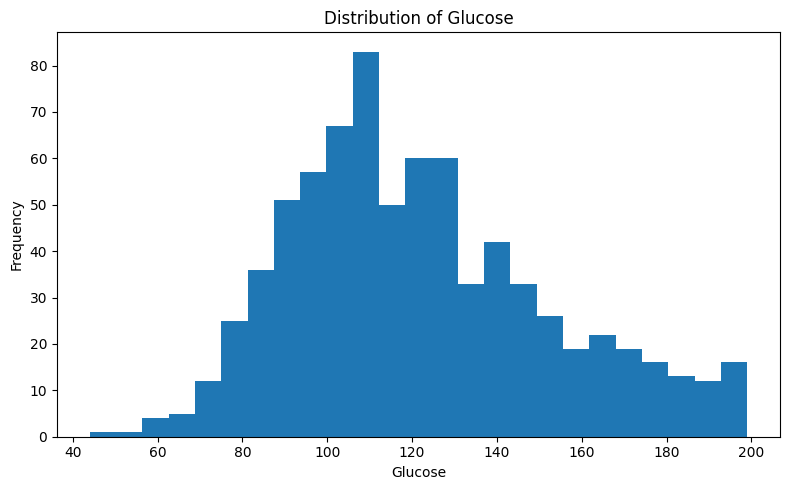

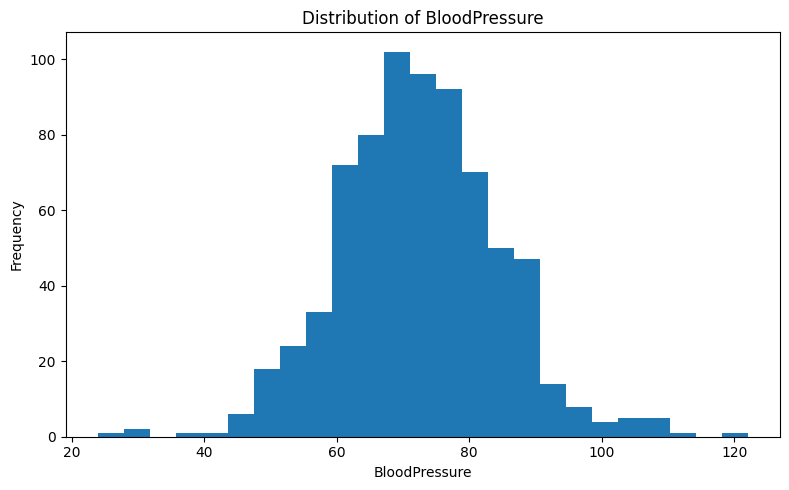

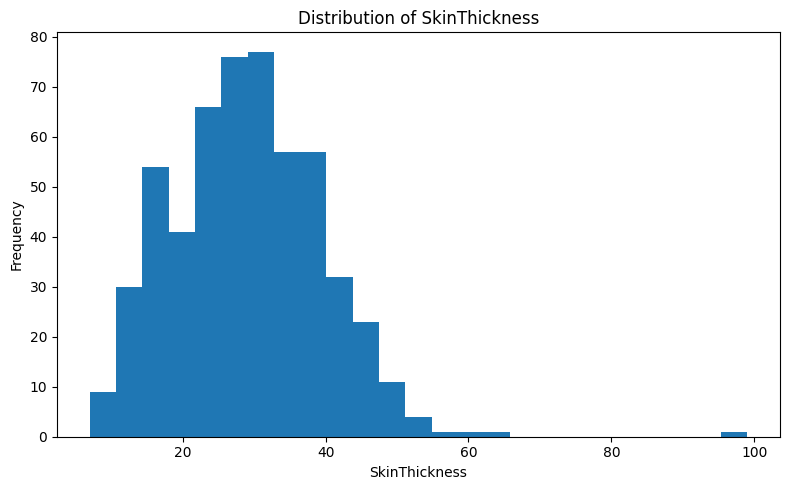

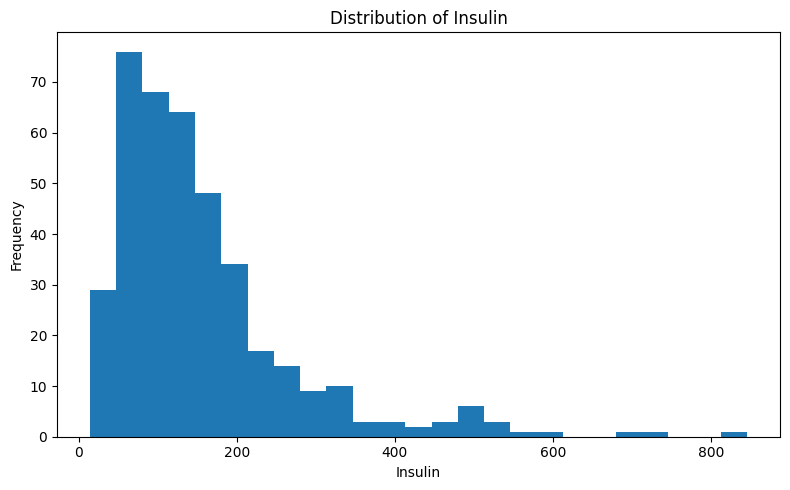

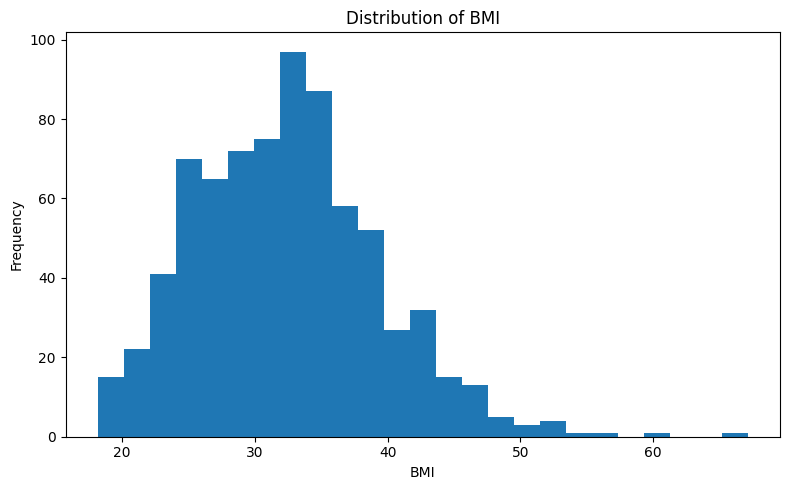

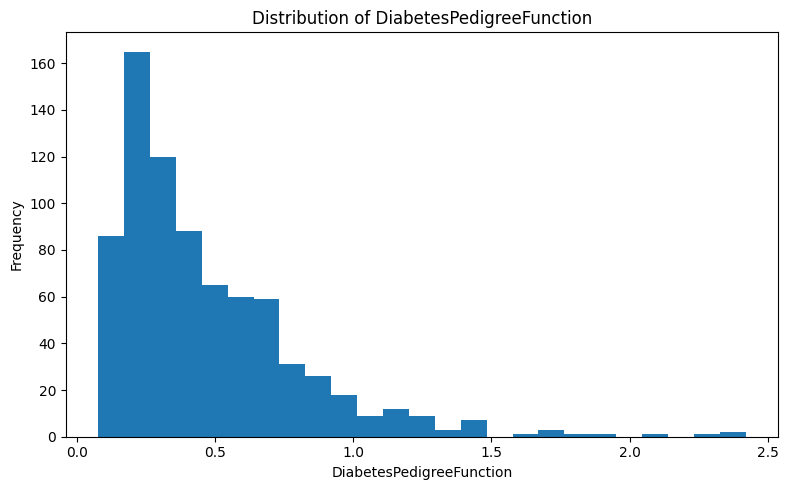

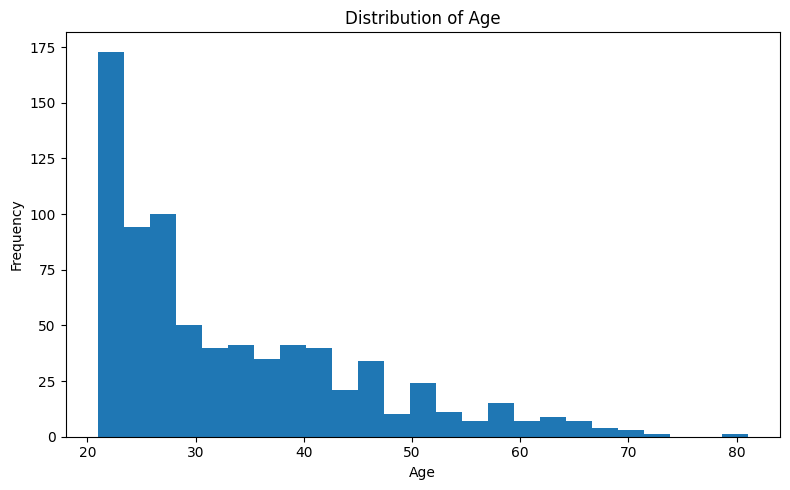

In [15]:
# STEP 9 — Histograms for all numerical features
feature_cols = [c for c in df_model.columns if c != "Outcome"]

for col in feature_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df_model[col].dropna(), bins=25)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


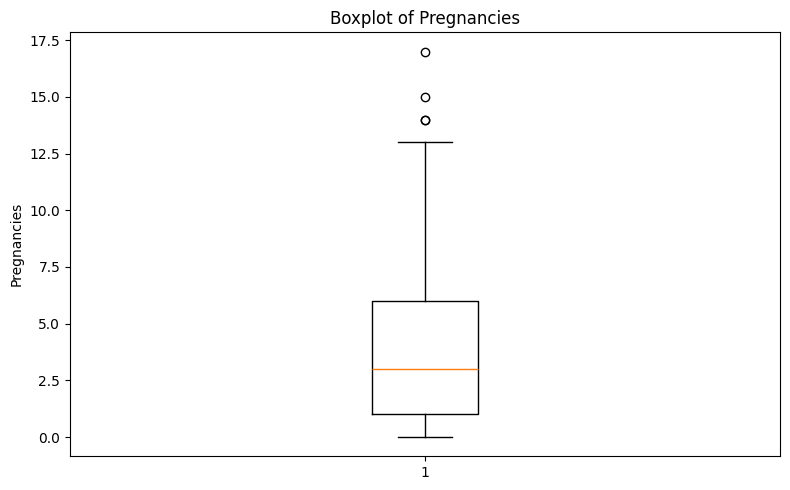

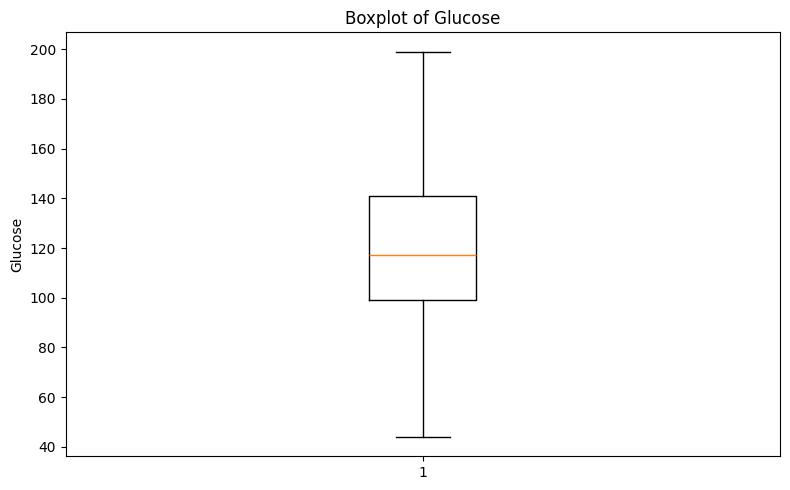

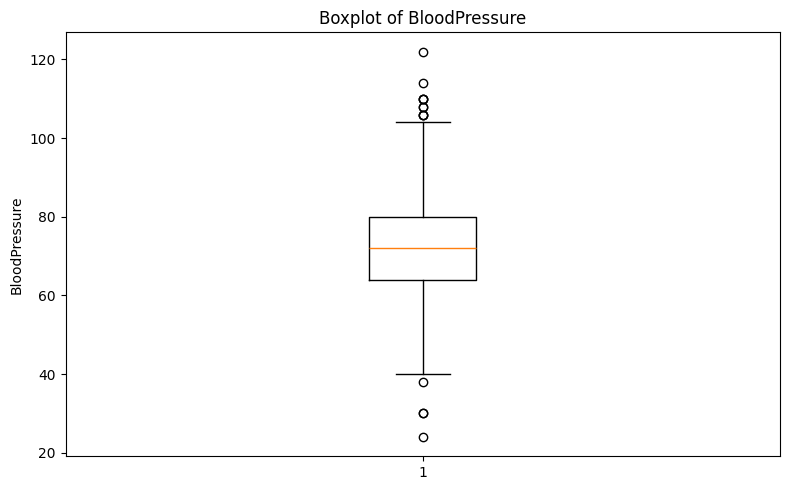

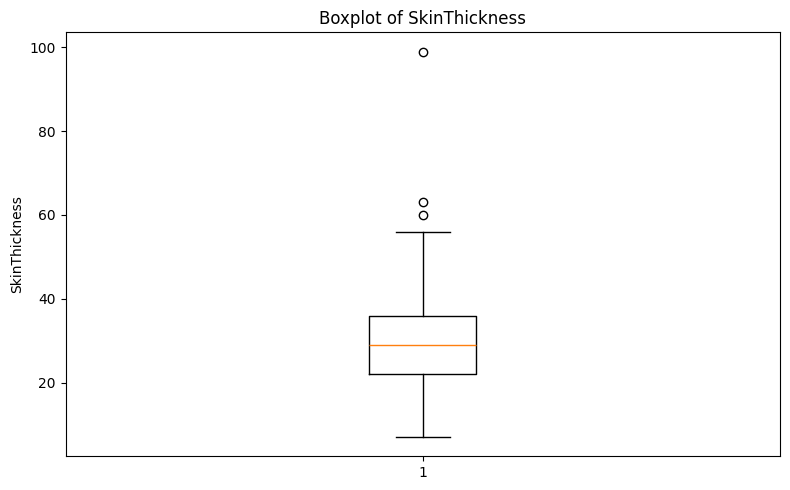

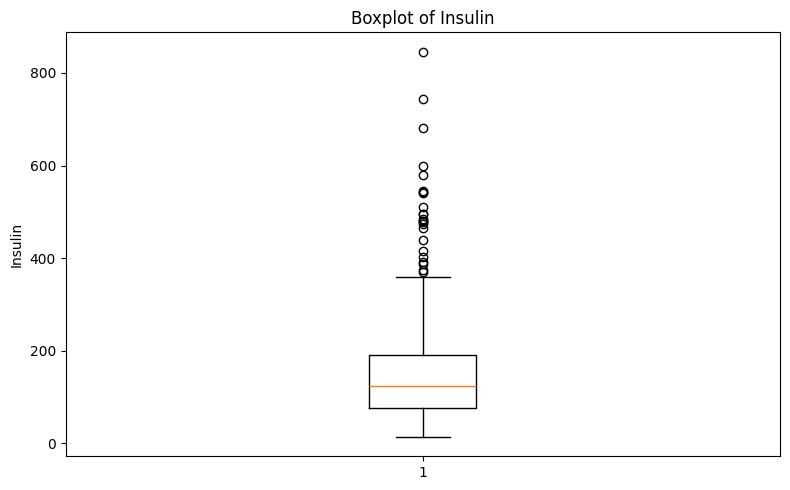

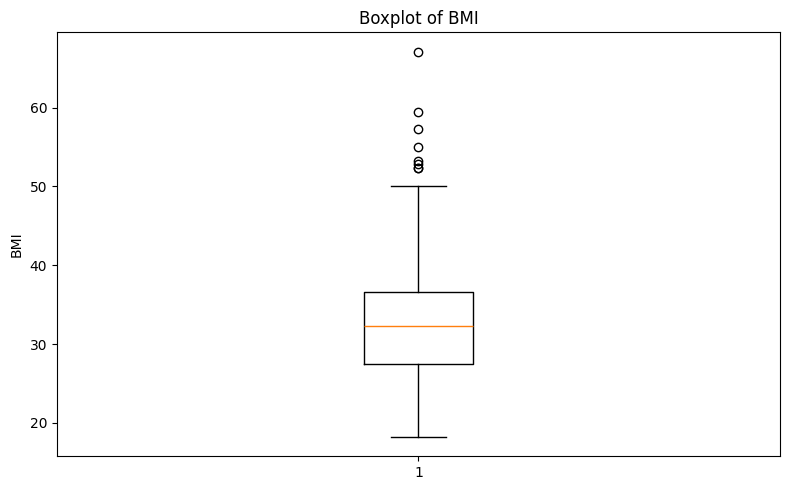

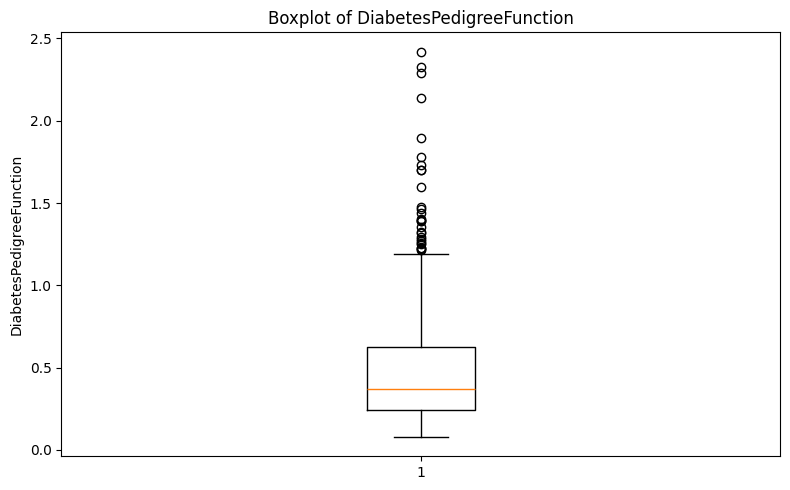

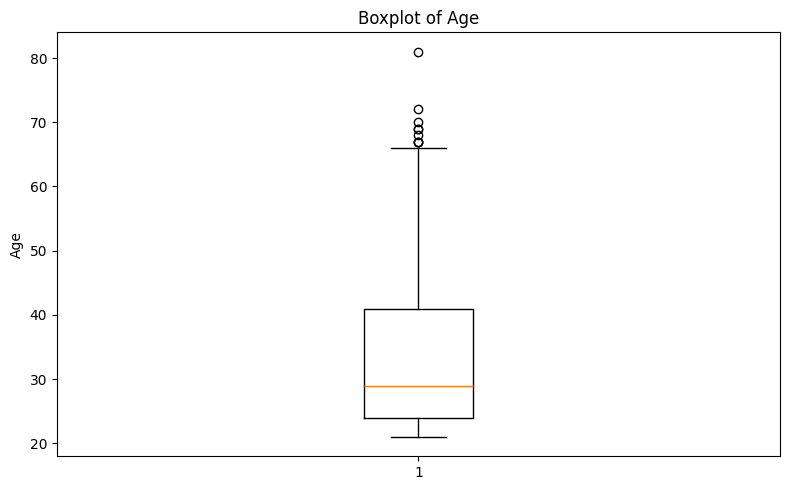

In [16]:
# STEP 10 — Boxplots for all numerical features
for col in feature_cols:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_model[col].dropna(), vert=True)
    plt.ylabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


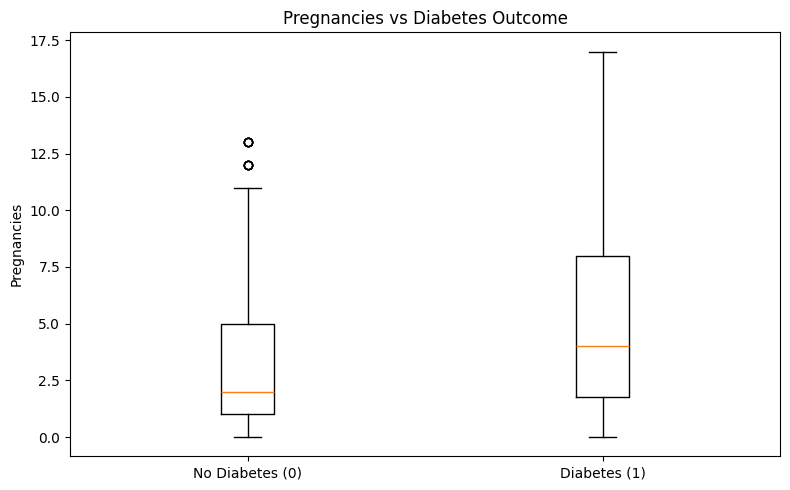

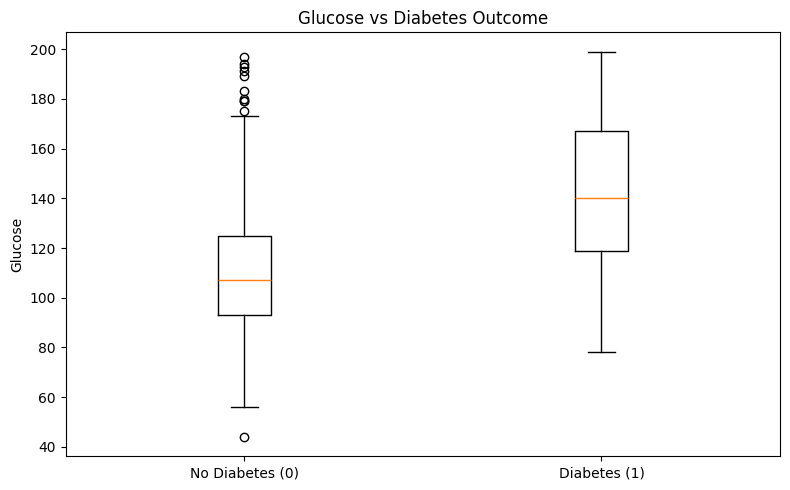

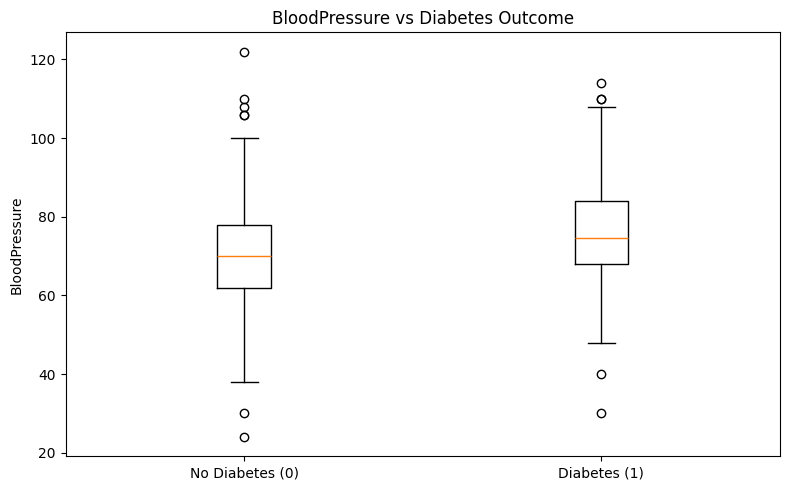

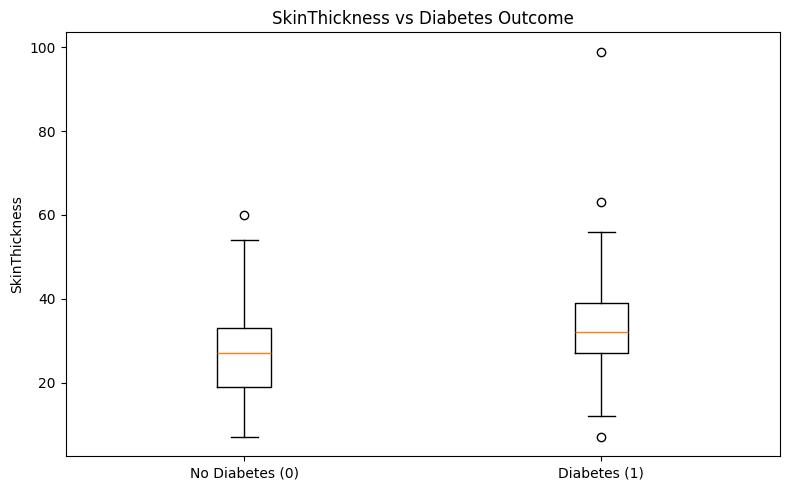

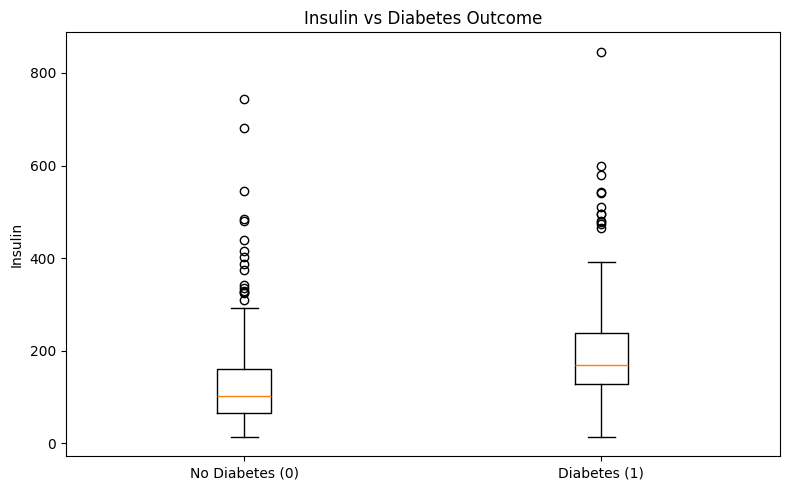

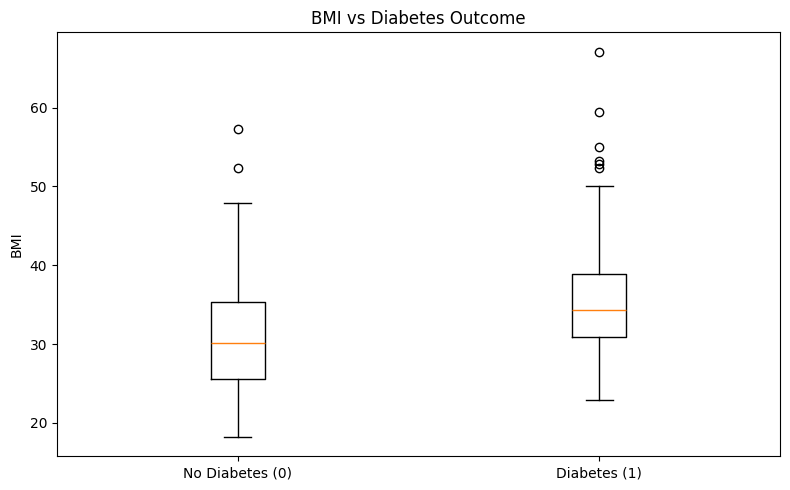

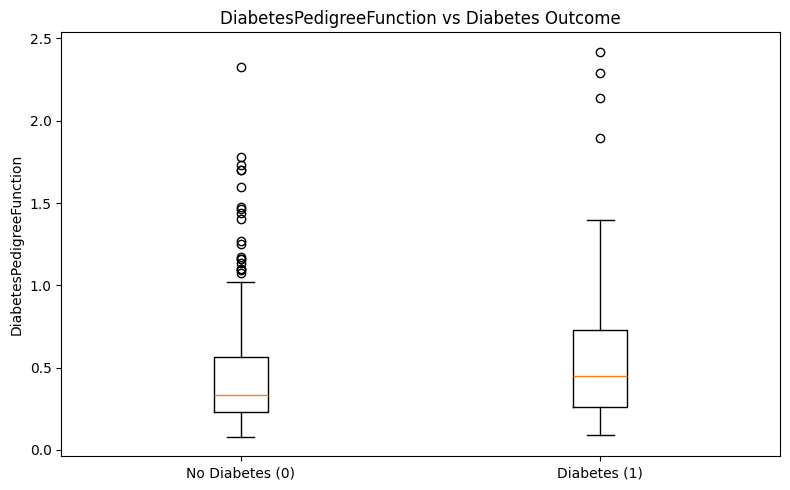

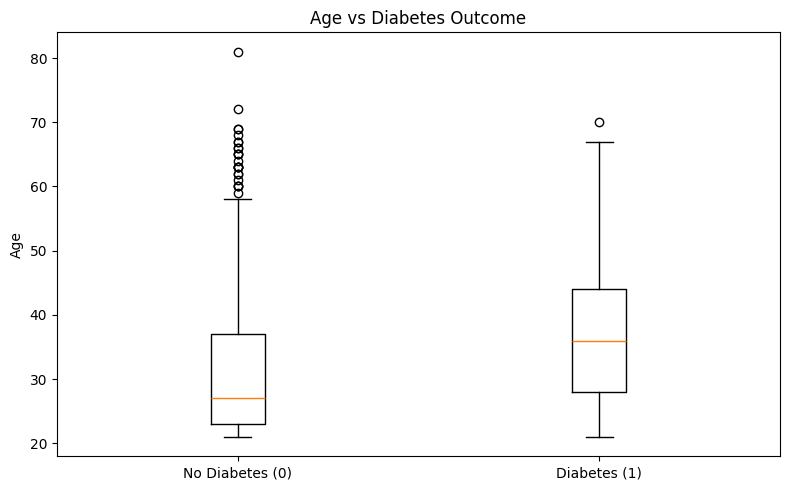

In [17]:
# STEP 11 — Feature vs Diabetes: boxplots
for col in feature_cols:
    group0 = df_model.loc[df_model["Outcome"] == 0, col].dropna()
    group1 = df_model.loc[df_model["Outcome"] == 1, col].dropna()

    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [group0, group1],
        labels=["No Diabetes (0)", "Diabetes (1)"]
    )
    plt.ylabel(col)
    plt.title(f"{col} vs Diabetes Outcome")
    plt.tight_layout()
    plt.show()


Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,110.643863,142.319549
BloodPressure,70.877339,75.321429
SkinThickness,27.235457,33.000000
Insulin,130.287879,206.846154
BMI,30.859674,35.406767
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


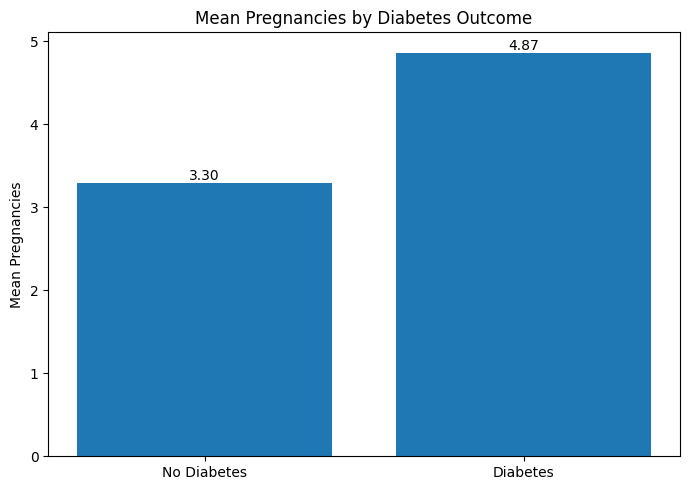

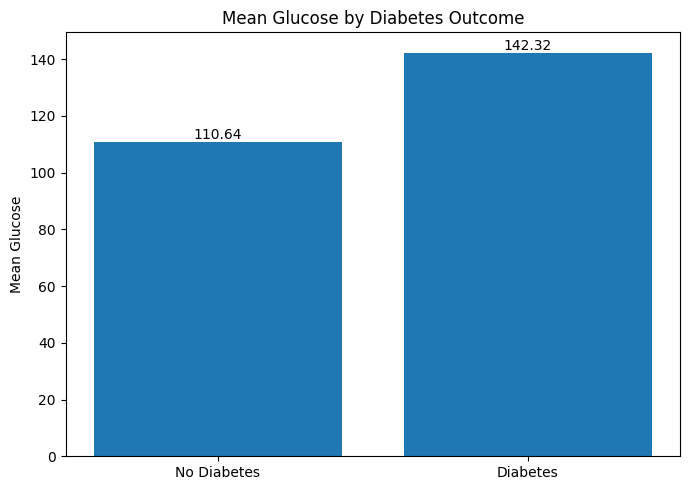

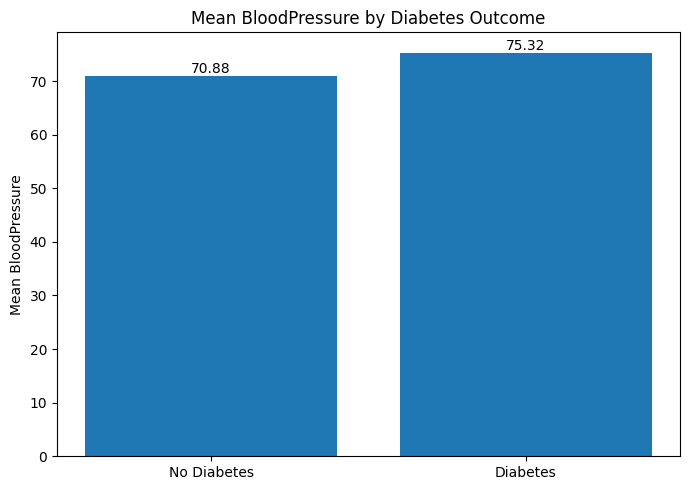

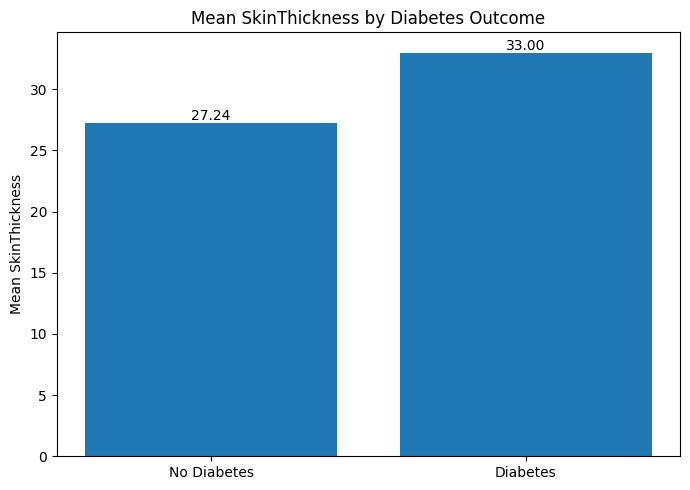

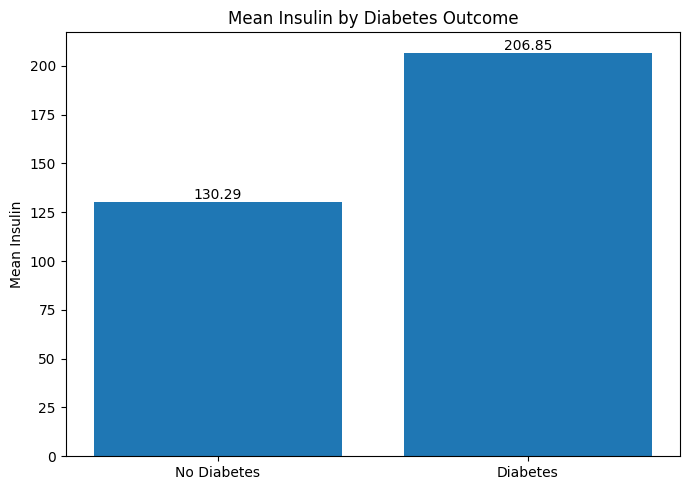

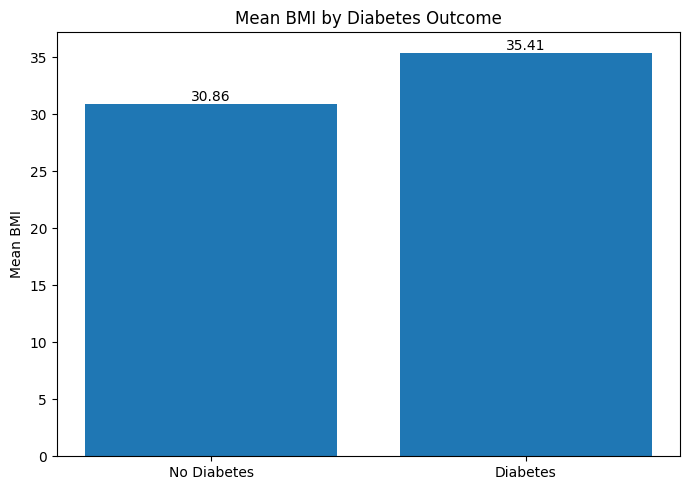

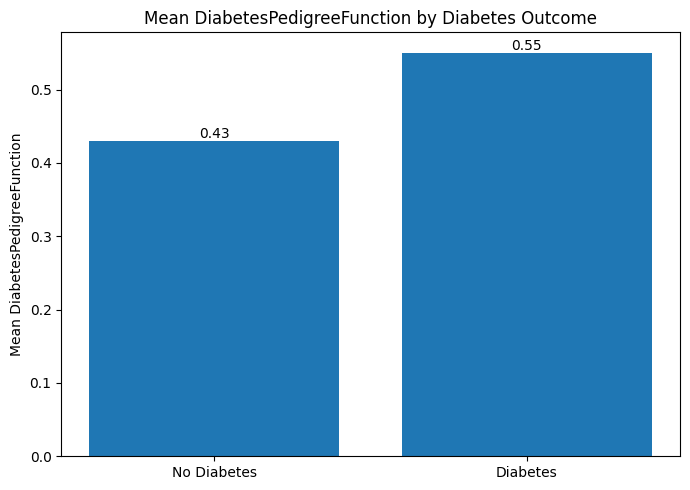

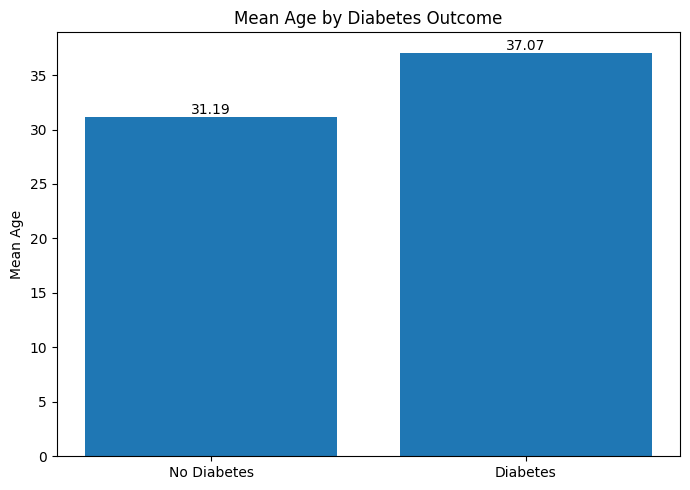

In [18]:
# STEP 12 — Feature vs Diabetes: mean comparison
mean_by_target = df_model.groupby("Outcome")[feature_cols].mean().T

display(mean_by_target)

for col in feature_cols:
    means = df_model.groupby("Outcome")[col].mean()

    plt.figure(figsize=(7, 5))
    plt.bar(["No Diabetes", "Diabetes"], means.values)
    plt.ylabel(f"Mean {col}")
    plt.title(f"Mean {col} by Diabetes Outcome")

    for i, v in enumerate(means.values):
        plt.text(i, v, f"{v:.2f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()


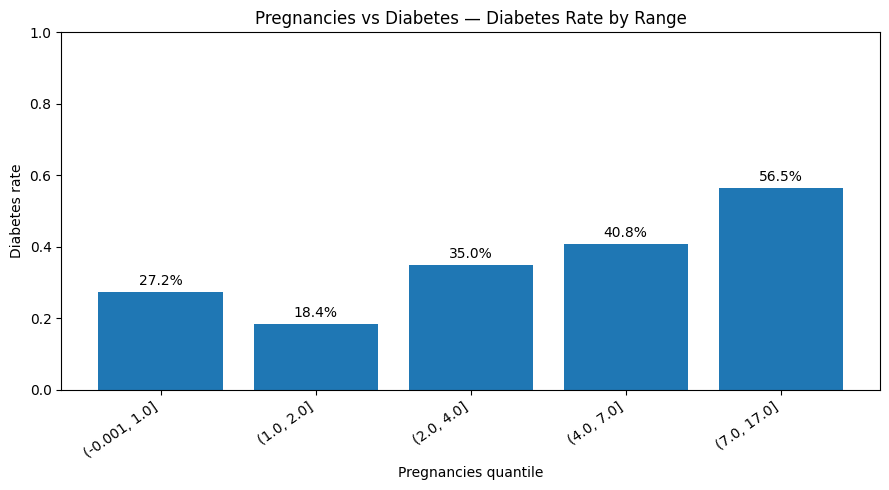

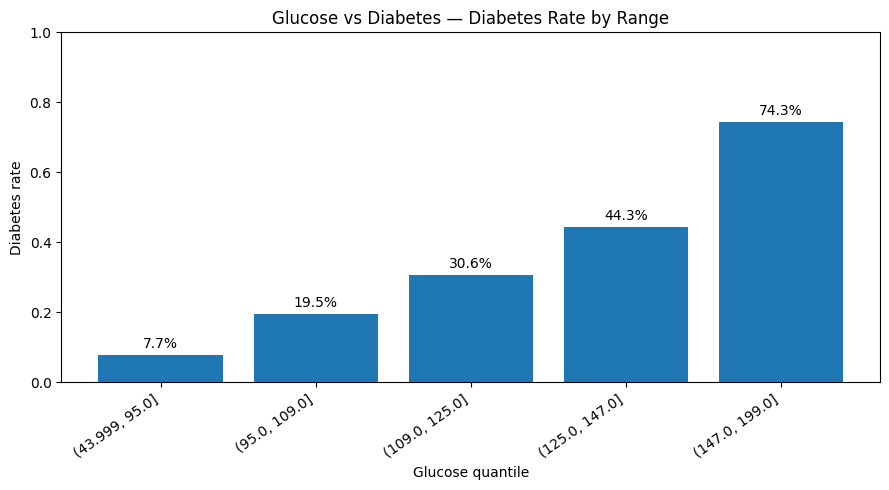

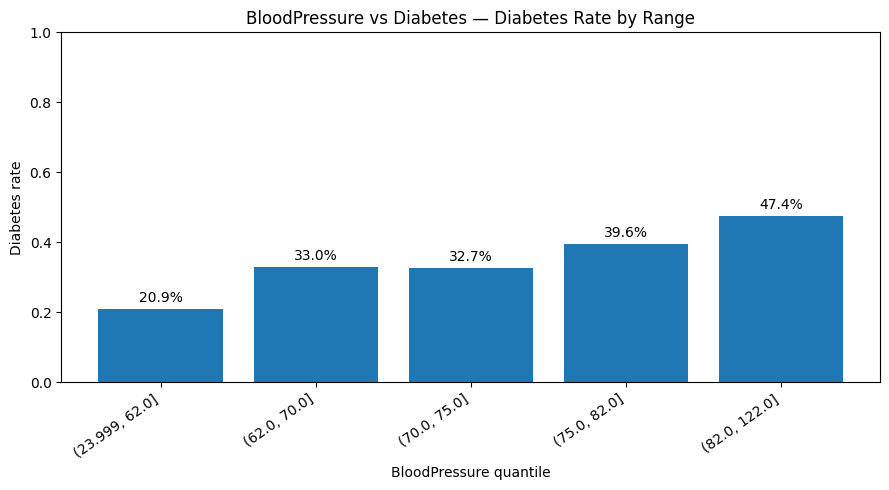

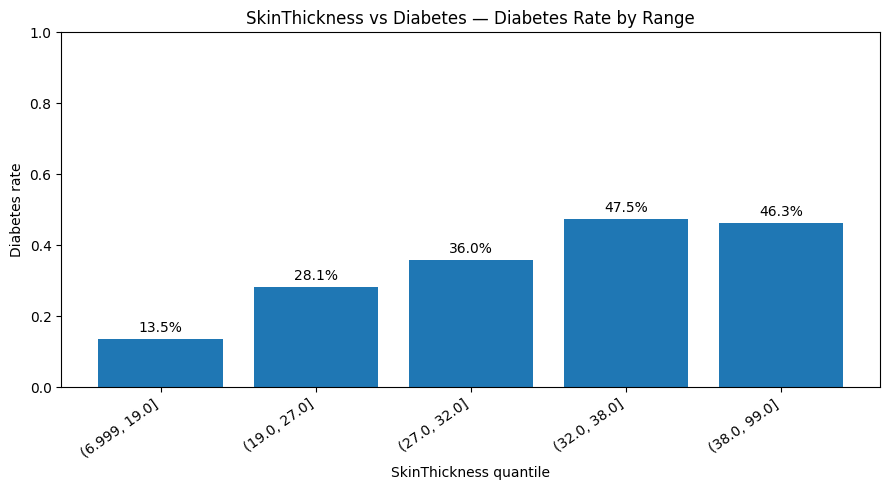

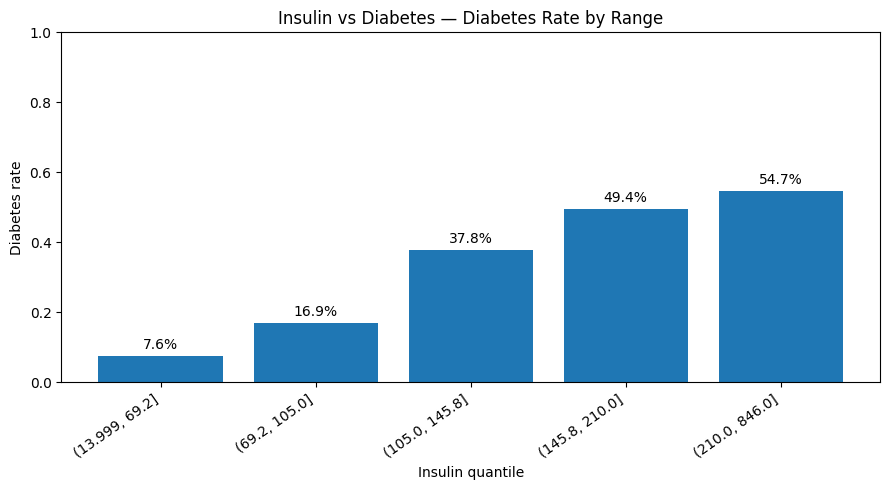

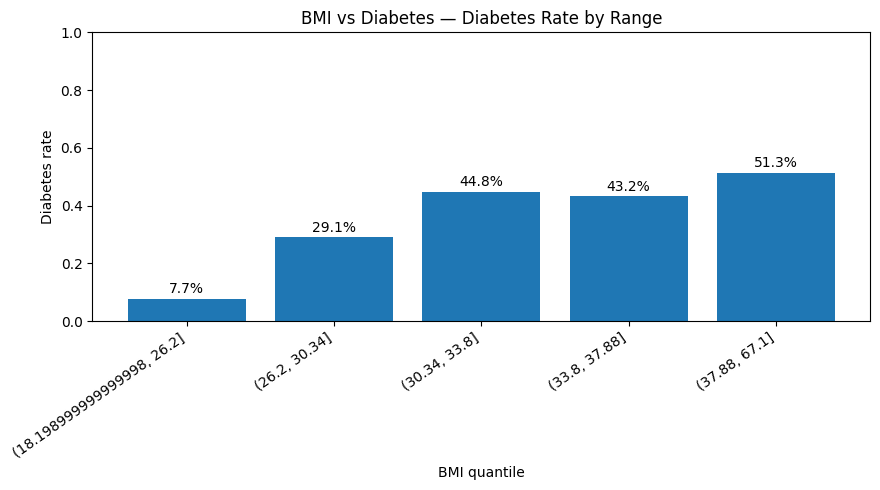

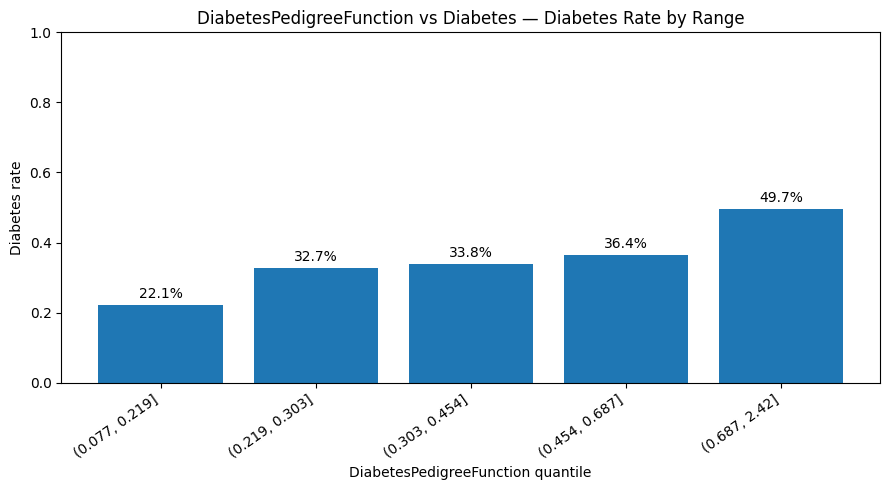

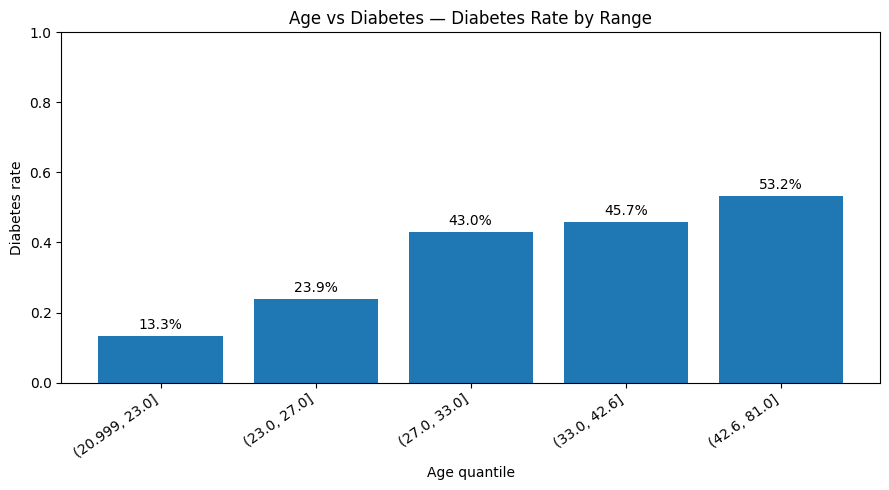

In [19]:
# STEP 13 — Binned feature vs Diabetes: disease rate
for col in feature_cols:
    temp = df_model[[col, "Outcome"]].dropna().copy()

    # Use quantile bins where possible
    try:
        temp["bin"] = pd.qcut(temp[col], q=5, duplicates="drop")
    except ValueError:
        continue

    grouped = temp.groupby("bin", observed=True)["Outcome"].agg(
        ["mean", "count"]
    ).reset_index()

    plt.figure(figsize=(9, 5))
    x = np.arange(len(grouped))
    plt.bar(x, grouped["mean"])
    plt.xticks(x, grouped["bin"].astype(str), rotation=35, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Diabetes rate")
    plt.xlabel(f"{col} quantile")
    plt.title(f"{col} vs Diabetes — Diabetes Rate by Range")

    for i, v in enumerate(grouped["mean"]):
        plt.text(i, min(v + 0.02, 0.98), f"{v:.1%}", ha="center")

    plt.tight_layout()
    plt.show()


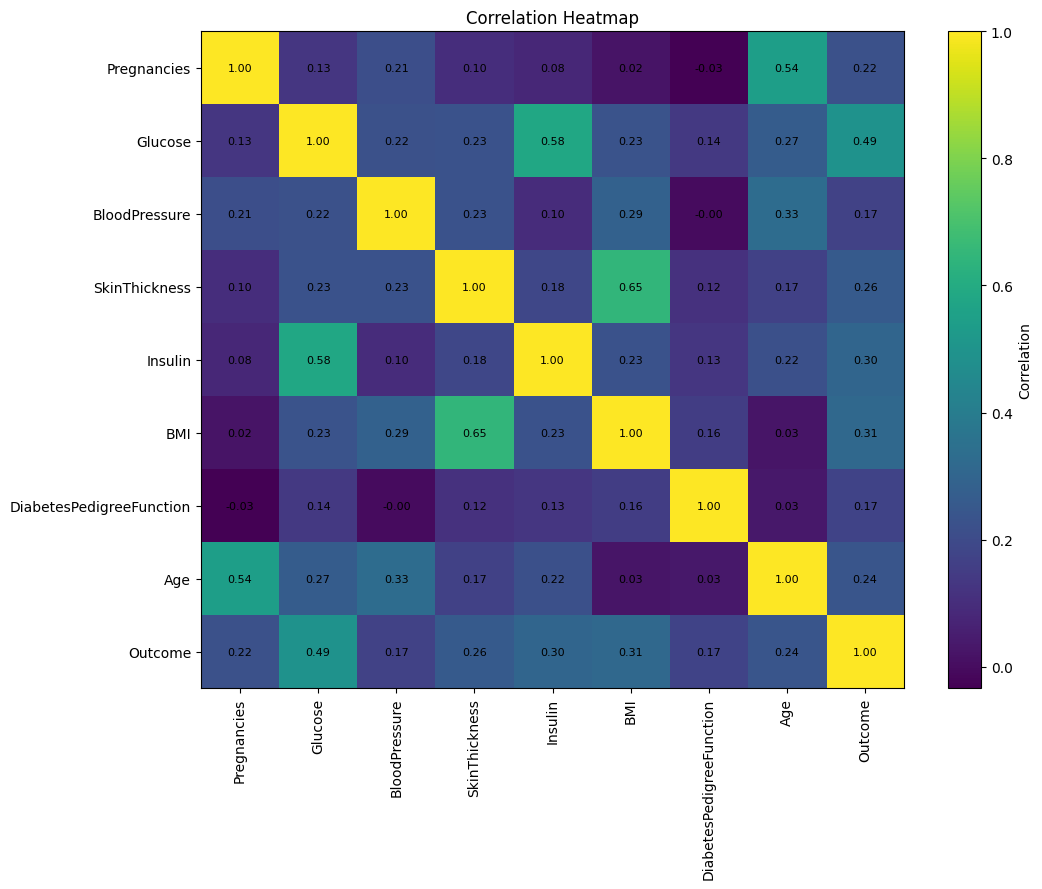

Correlation with Outcome:


,correlation_with_outcome
Outcome,1.000000
Glucose,0.494650
BMI,0.313680
Insulin,0.303454
SkinThickness,0.259491
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
BloodPressure,0.170589


In [20]:
# STEP 14 — Correlation matrix
corr = df_model.corr(numeric_only=True)

plt.figure(figsize=(11, 9))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with Outcome:")
display(
    corr["Outcome"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_outcome")
)


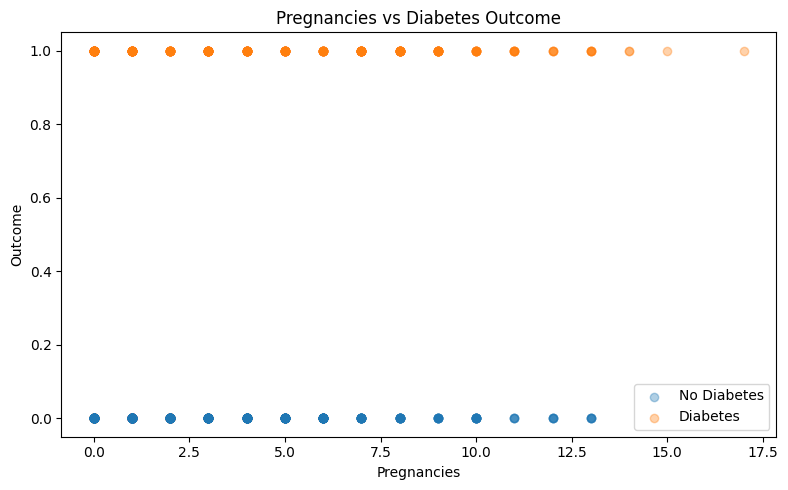

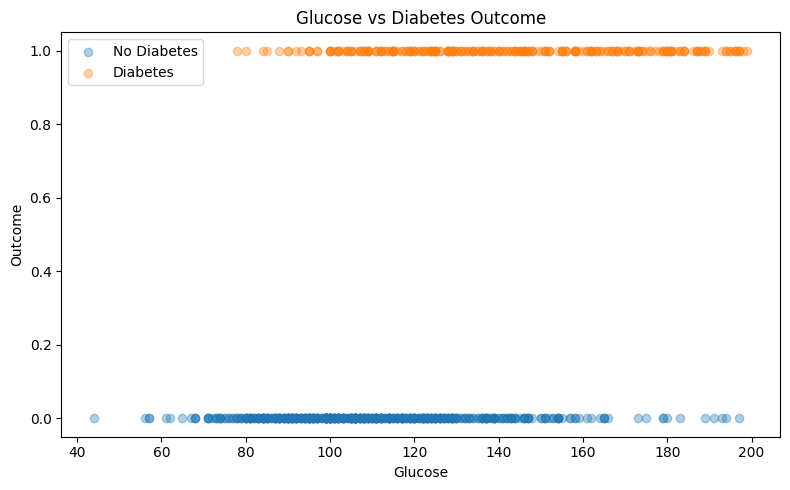

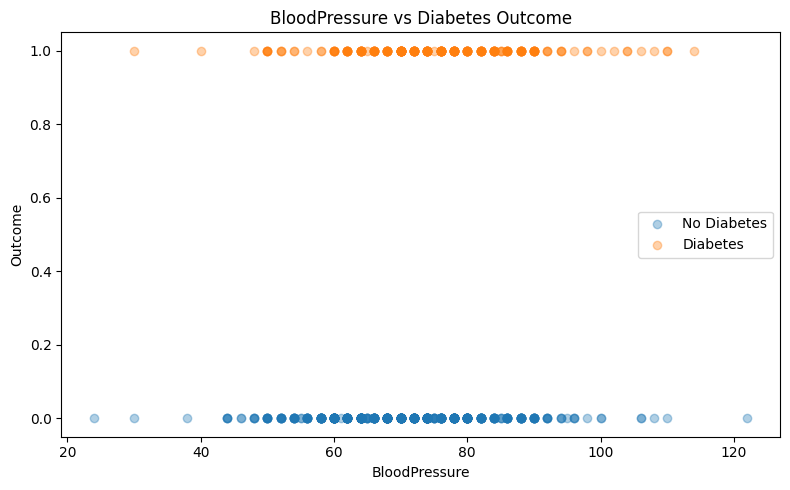

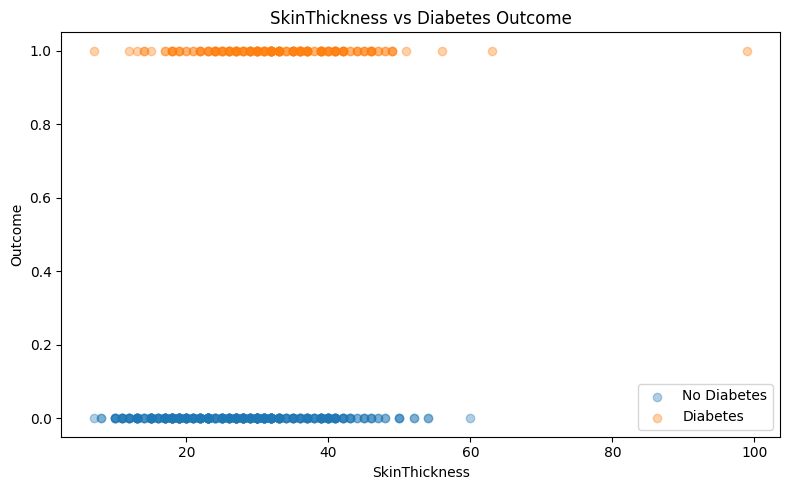

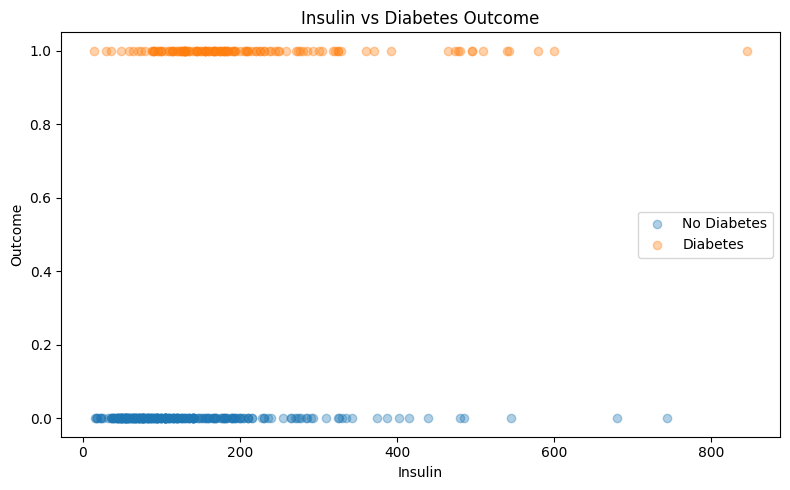

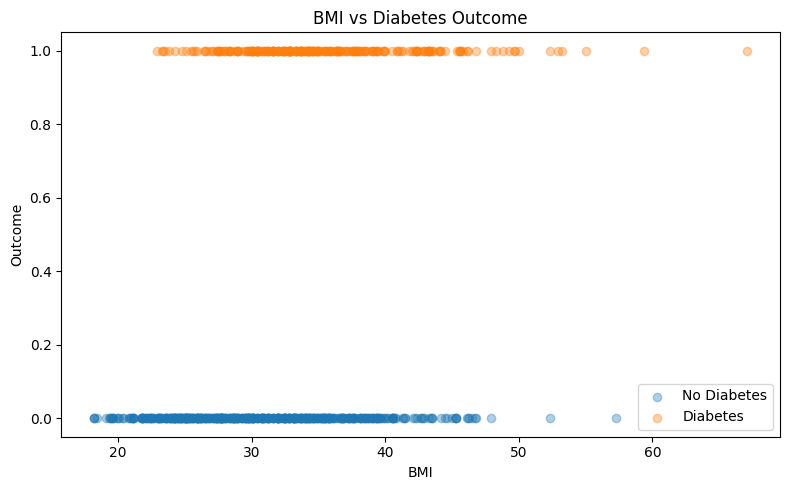

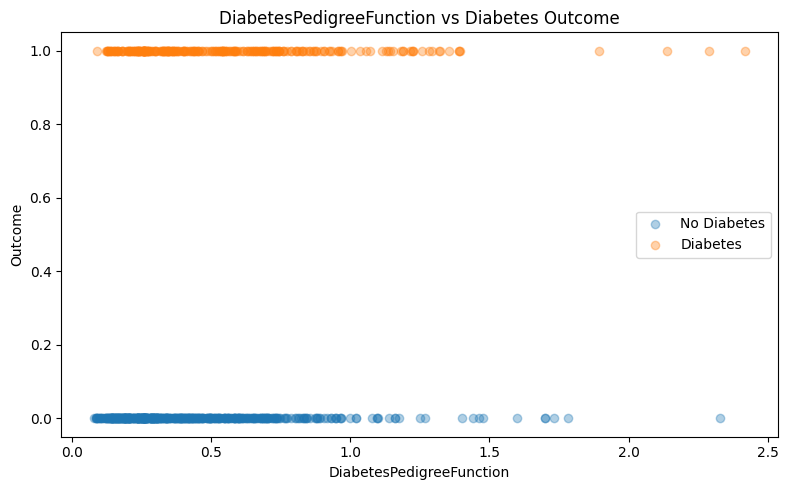

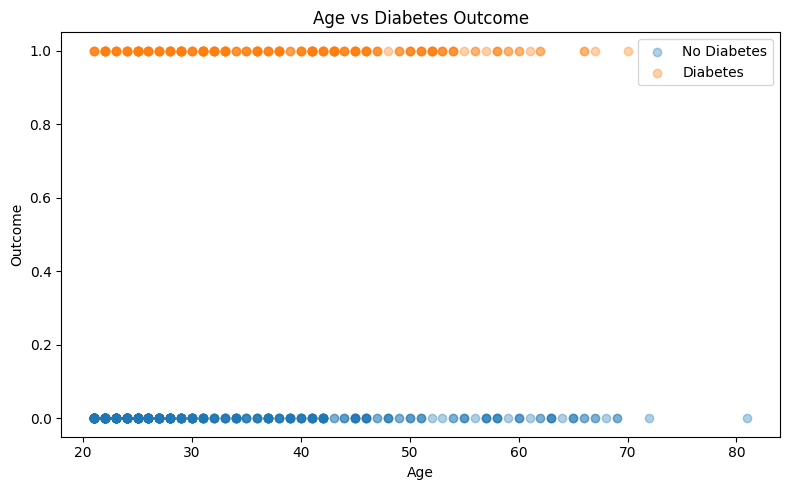

In [21]:
# STEP 15 — Pairwise scatter plots against Outcome
# A compact pairwise view for every feature vs Outcome.
for col in feature_cols:
    plt.figure(figsize=(8, 5))

    for outcome_value in [0, 1]:
        subset = df_model[df_model["Outcome"] == outcome_value]
        plt.scatter(
            subset[col],
            subset["Outcome"],
            alpha=0.35,
            label="No Diabetes" if outcome_value == 0 else "Diabetes"
        )

    plt.xlabel(col)
    plt.ylabel("Outcome")
    plt.title(f"{col} vs Diabetes Outcome")
    plt.legend()
    plt.tight_layout()
    plt.show()


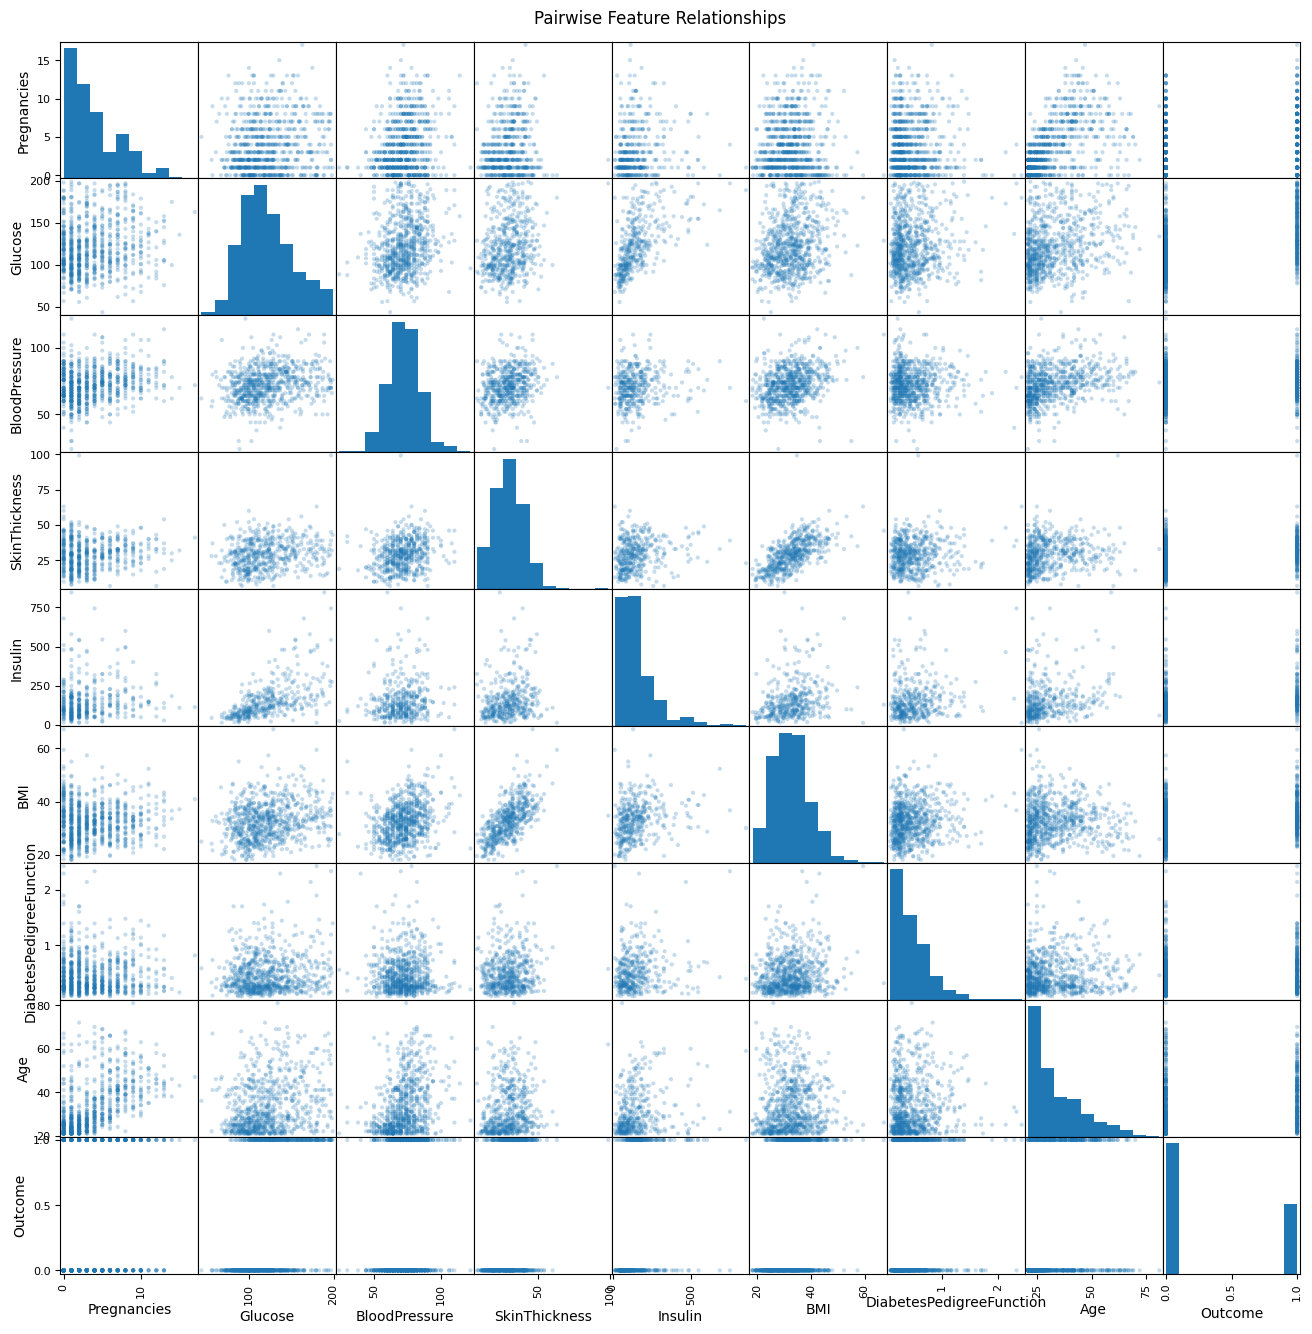

In [22]:
# STEP 16 — Pairwise feature relationship matrix using pandas
# This can be computationally heavier on larger datasets.
pd.plotting.scatter_matrix(
    df_model[feature_cols + ["Outcome"]],
    figsize=(16, 16),
    diagonal="hist",
    alpha=0.25
)
plt.suptitle("Pairwise Feature Relationships", y=0.90)
plt.show()


In [23]:
# STEP 17 — Separate features and target
X = df_model.drop(columns="Outcome")
y = df_model["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (768, 8)
y shape: (768,)


In [24]:
# STEP 18 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).sort_index())


Training rows: 614
Testing rows : 154

Training target distribution:


,proportion
Outcome,
0,0.651466
1,0.348534



Testing target distribution:


,proportion
Outcome,
0,0.649351
1,0.350649


In [25]:
# STEP 19 — Preprocessing pipeline
# Median imputation handles missing values.
# StandardScaler is important for Logistic Regression, SVM and KNN.
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [26]:
# STEP 20 — Define all models
models = {
    "Linear Regression": LinearRegression(),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    )
}


In [27]:
# STEP 21 — Train every model and calculate evaluation metrics
results = []
trained_models = {}
predictions = {}
scores = {}

for name, estimator in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipe.fit(X_train, y_train)

    if name == "Linear Regression":
        y_score = pipe.predict(X_test)
        y_pred = (y_score >= 0.5).astype(int)

        mae = mean_absolute_error(y_test, y_score)
        rmse = np.sqrt(mean_squared_error(y_test, y_score))
        r2 = r2_score(y_test, y_score)

    else:
        y_pred = pipe.predict(X_test)
        y_score = pipe.predict_proba(X_test)[:, 1]

        mae = np.nan
        rmse = np.nan
        r2 = np.nan

    trained_models[name] = pipe
    predictions[name] = y_pred
    scores[name] = y_score

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MAE,RMSE,R2
0,Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622,0.5854,NaN,NaN,NaN
1,SVM,0.7403,0.6522,0.5556,0.6000,0.7964,0.6615,NaN,NaN,NaN
2,Random Forest,0.7403,0.6591,0.5370,0.5918,0.8160,0.6989,NaN,NaN,NaN
3,KNN,0.7273,0.6250,0.5556,0.5882,0.7900,0.6391,NaN,NaN,NaN
4,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130,0.6733,NaN,NaN,NaN
5,Linear Regression,0.7013,0.5909,0.4815,0.5306,0.8126,0.6708,0.3344,0.4144,0.2459


In [28]:
# STEP 22 — Detailed classification reports
for name in models:
    print("\n" + "=" * 75)
    print(name)
    print("=" * 75)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["No Diabetes", "Diabetes"],
            zero_division=0
        )
    )



Linear Regression
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154


Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Decision Tree
              precision    recall  f1-score   support

 No Diabetes       0.84      0.78      0.81       100
    Diabetes       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       

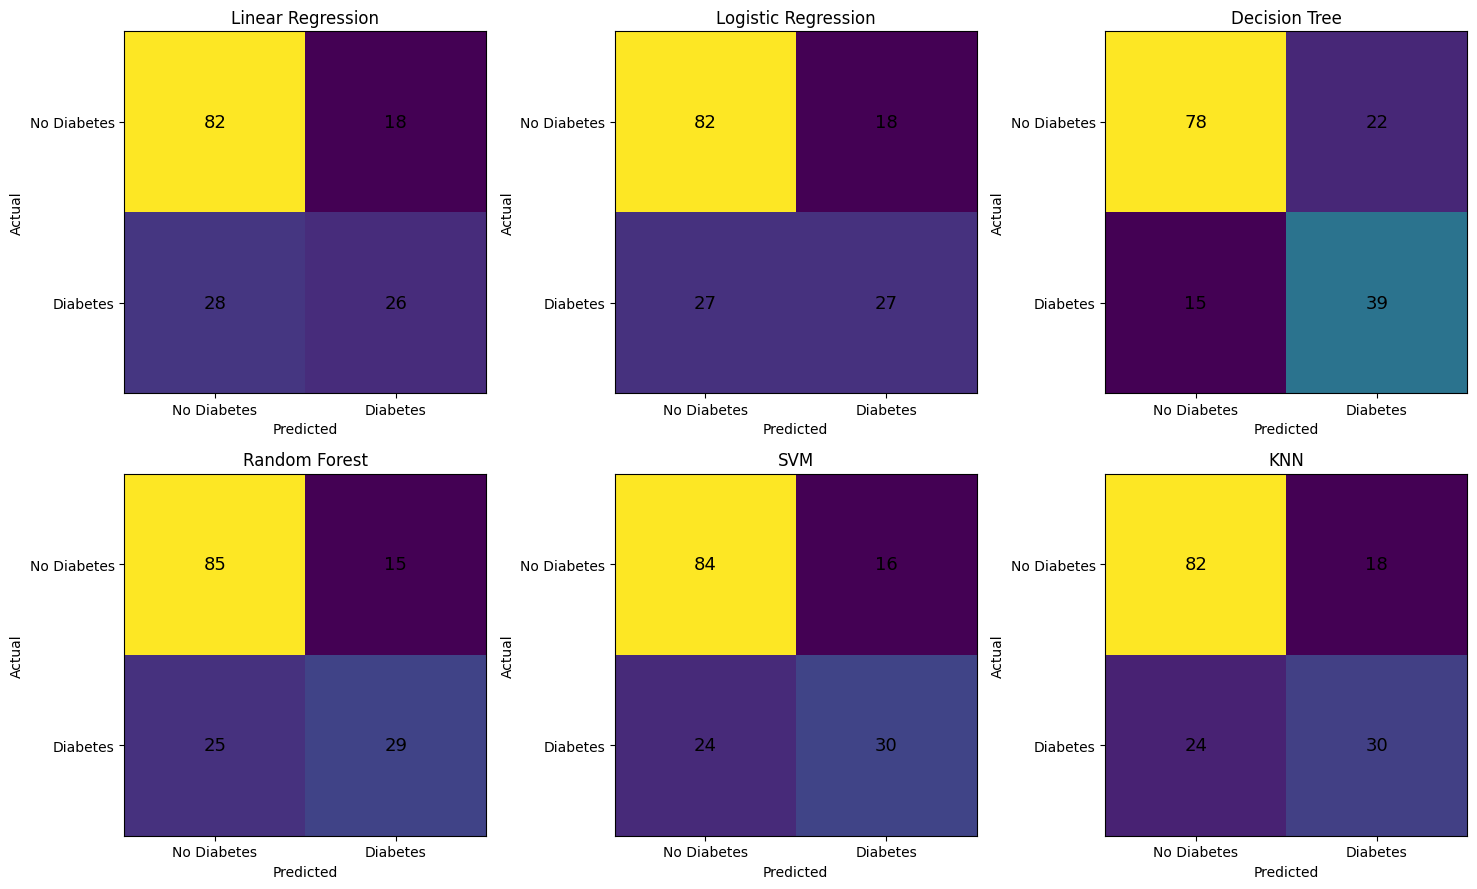

In [29]:
# STEP 23 — Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])

    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No Diabetes", "Diabetes"])
    ax.set_yticklabels(["No Diabetes", "Diabetes"])

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=13
            )

plt.tight_layout()
plt.show()


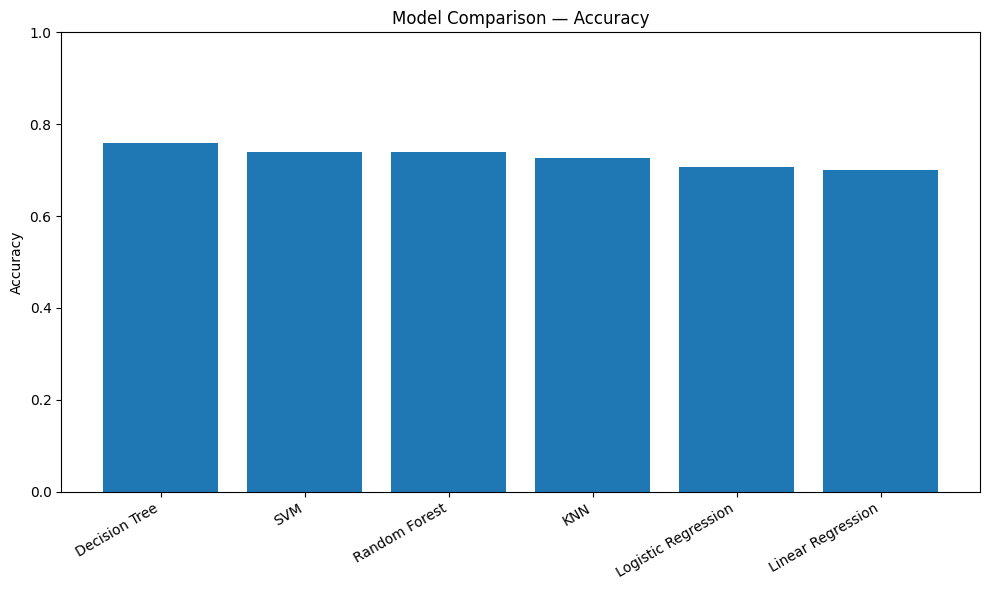

In [30]:
# STEP 24 — Metric comparison: Accuracy
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Comparison — Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


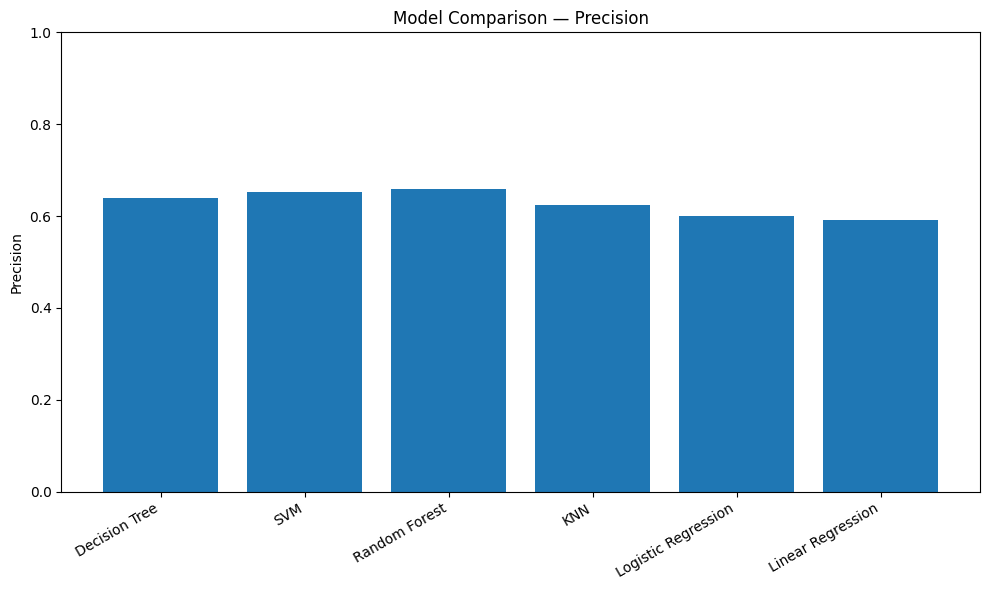

In [31]:
# STEP 25 — Metric comparison: Precision
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Precision"])
plt.ylim(0, 1)
plt.ylabel("Precision")
plt.title("Model Comparison — Precision")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


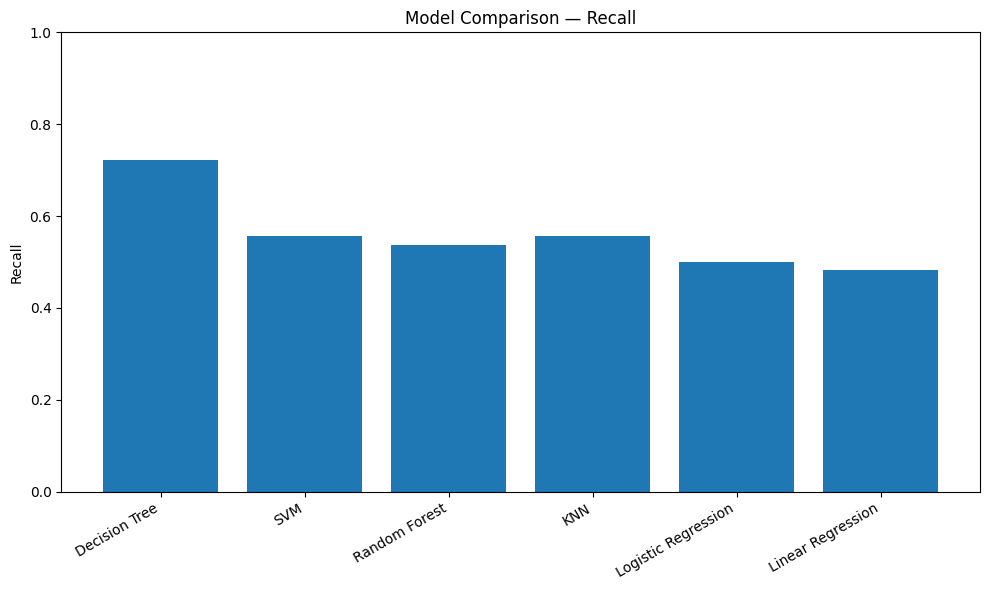

In [32]:
# STEP 26 — Metric comparison: Recall
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Recall"])
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Model Comparison — Recall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


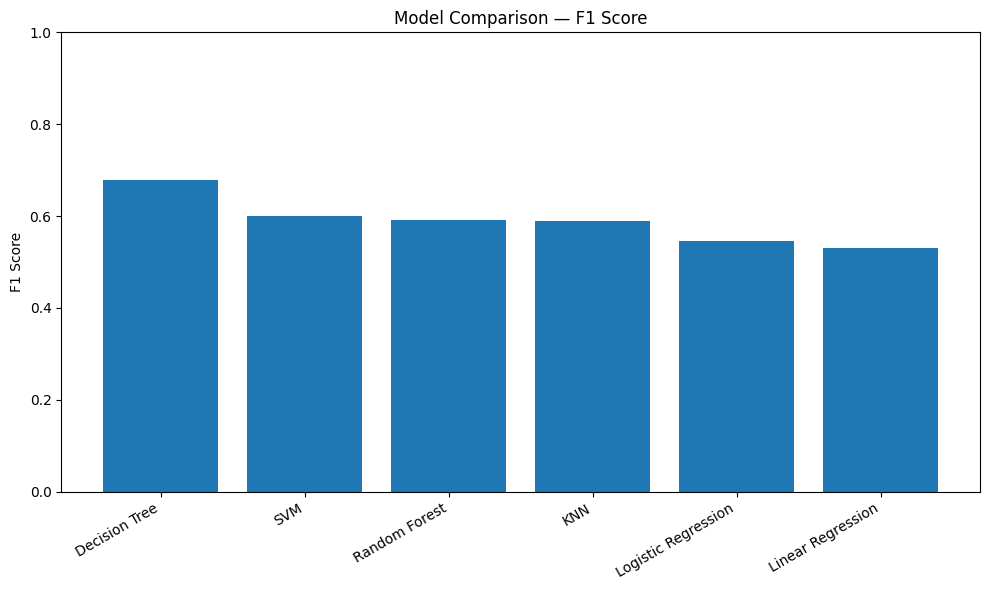

In [33]:
# STEP 27 — Metric comparison: F1 Score
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["F1"])
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Model Comparison — F1 Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


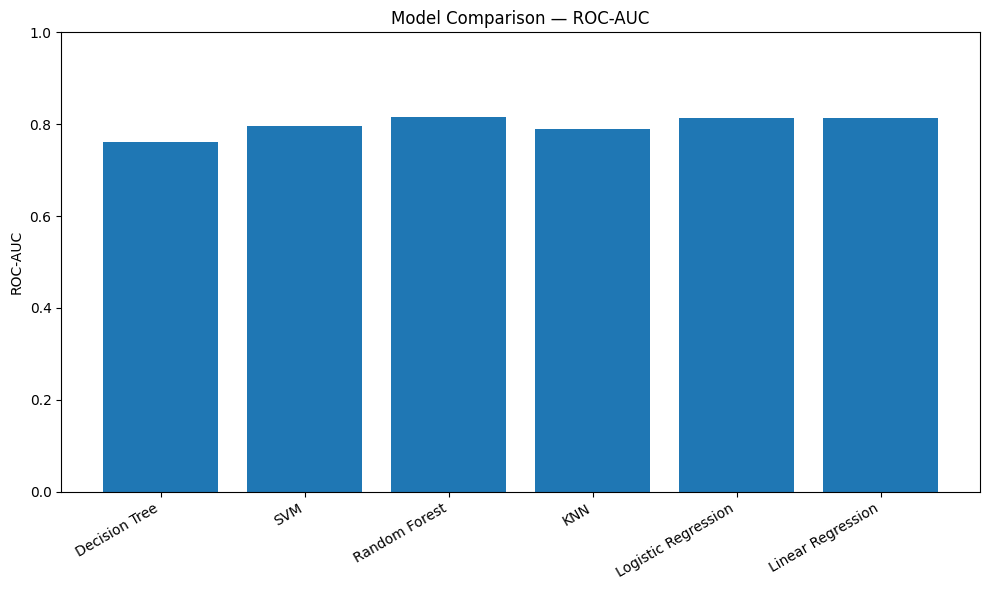

In [34]:
# STEP 28 — Metric comparison: ROC-AUC
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["ROC_AUC"])
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model Comparison — ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


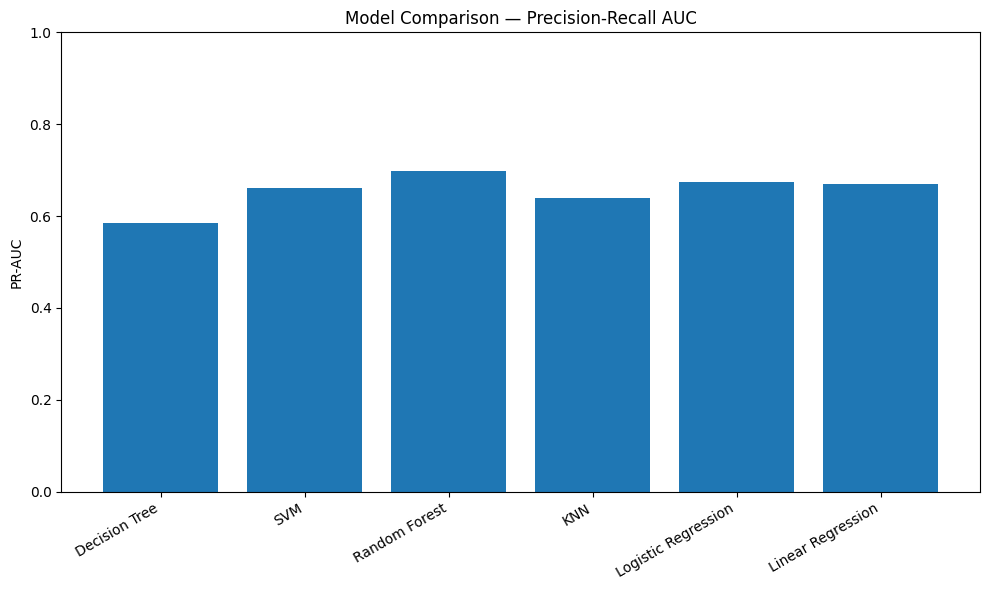

In [35]:
# STEP 29 — Metric comparison: PR-AUC
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["PR_AUC"])
plt.ylim(0, 1)
plt.ylabel("PR-AUC")
plt.title("Model Comparison — Precision-Recall AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


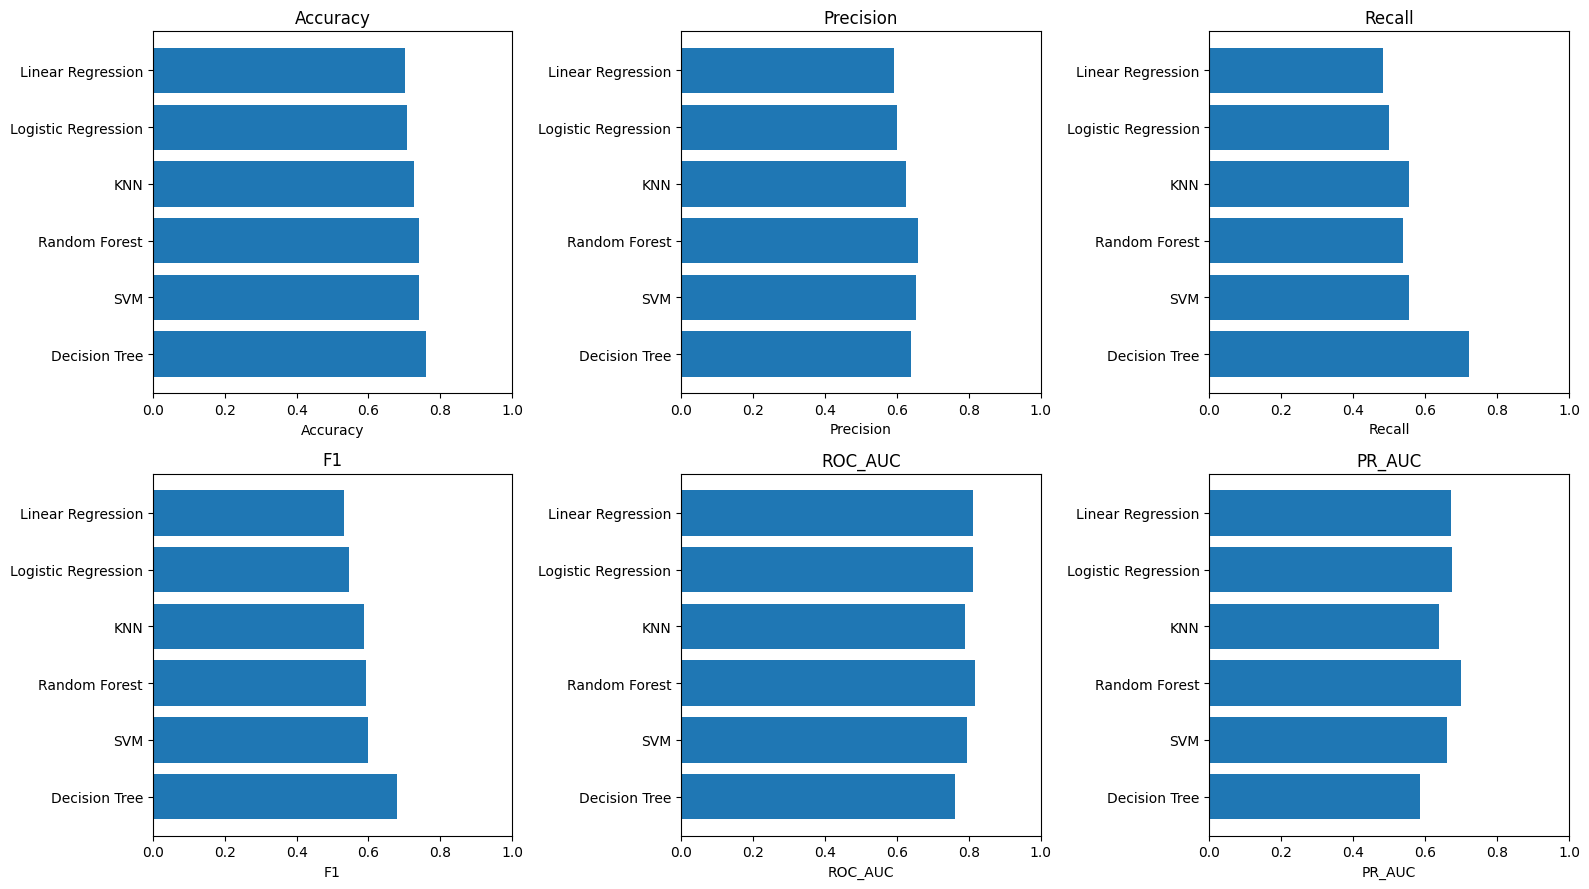

In [36]:
# STEP 30 — All classification metrics in one figure
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, metric in zip(axes, metric_cols):
    ax.barh(results_df["Model"], results_df[metric])
    ax.set_xlim(0, 1)
    ax.set_title(metric)
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()


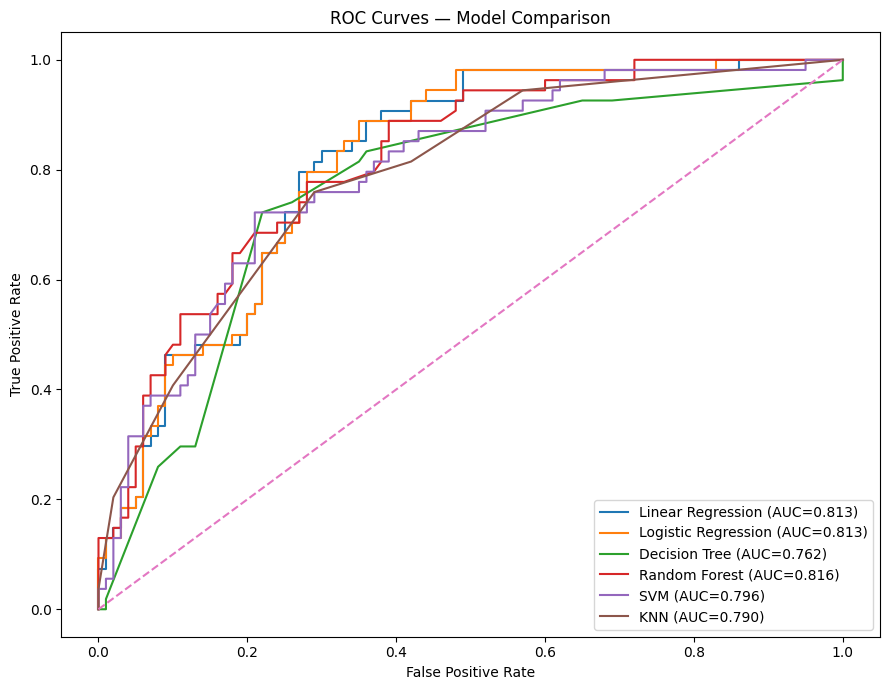

In [37]:
# STEP 31 — ROC curves for all models
plt.figure(figsize=(9, 7))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, scores[name])
    auc = roc_auc_score(y_test, scores[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


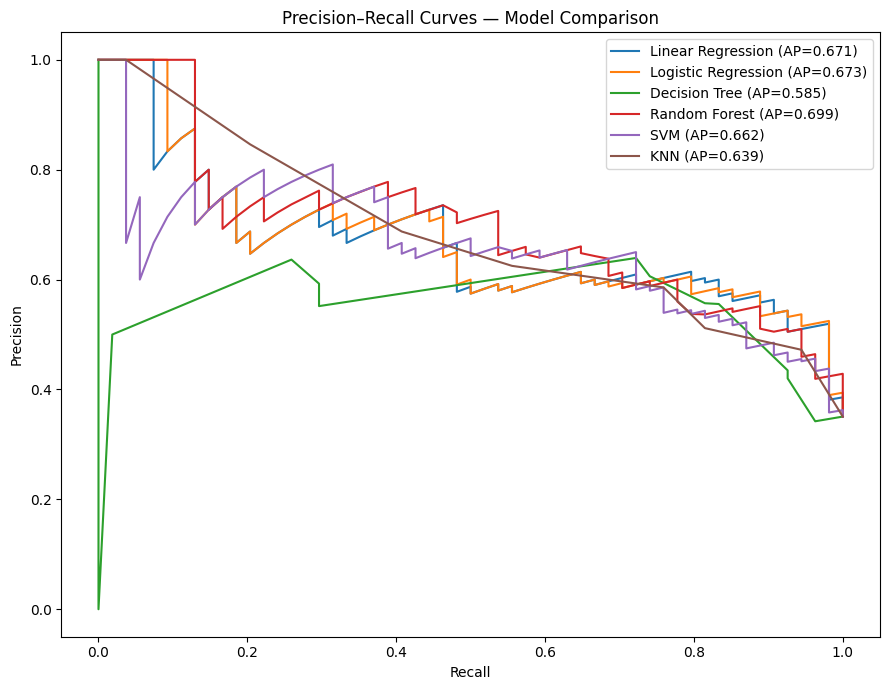

In [38]:
# STEP 32 — Precision-Recall curves for all models
plt.figure(figsize=(9, 7))

for name in models:
    precision, recall, _ = precision_recall_curve(
        y_test,
        scores[name]
    )
    ap = average_precision_score(y_test, scores[name])
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
# STEP 33 — 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name, estimator in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV ROC-AUC Mean": cv_scores.mean(),
        "CV ROC-AUC Std": cv_scores.std(),
        "Fold 1": cv_scores[0],
        "Fold 2": cv_scores[1],
        "Fold 3": cv_scores[2],
        "Fold 4": cv_scores[3],
        "Fold 5": cv_scores[4]
    })

cv_df = (
    pd.DataFrame(cv_rows)
    .sort_values("CV ROC-AUC Mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_df.round(4))


,Model,CV ROC-AUC Mean,CV ROC-AUC Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Logistic Regression,0.8434,0.0185,0.8669,0.8395,0.8512,0.8485,0.8107
1,SVM,0.8333,0.0228,0.8250,0.8262,0.8741,0.8049,0.8363
2,Random Forest,0.8209,0.0209,0.8382,0.8145,0.8517,0.7964,0.8039
3,KNN,0.7983,0.0329,0.8230,0.7735,0.8506,0.7650,0.7793
4,Decision Tree,0.7706,0.0286,0.8221,0.7407,0.7783,0.7616,0.7503
5,Linear Regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN


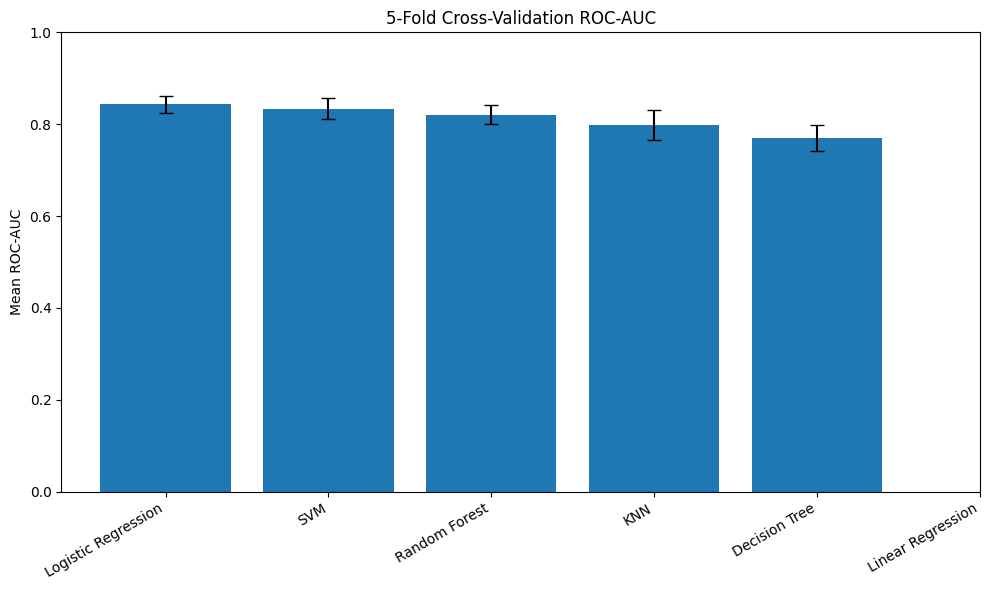

In [40]:
# STEP 34 — Cross-validation ROC-AUC comparison
plt.figure(figsize=(10, 6))

x = np.arange(len(cv_df))
means = cv_df["CV ROC-AUC Mean"]
stds = cv_df["CV ROC-AUC Std"]

plt.bar(x, means, yerr=stds, capsize=5)
plt.xticks(x, cv_df["Model"], rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean ROC-AUC")
plt.title("5-Fold Cross-Validation ROC-AUC")
plt.tight_layout()
plt.show()


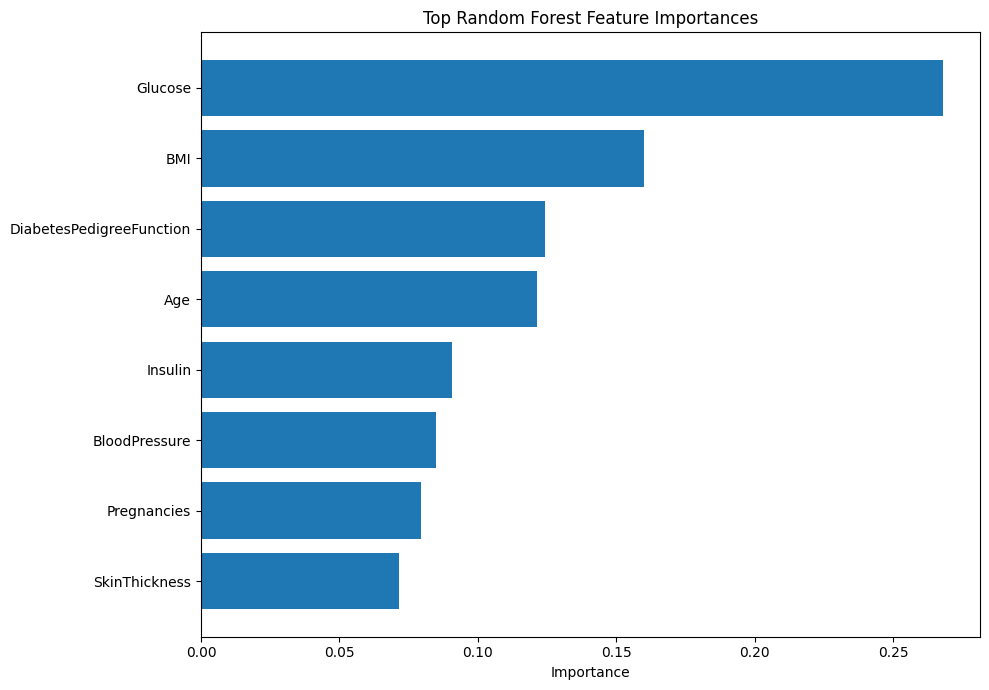

,Feature,Importance
0,Glucose,0.267931
1,BMI,0.159848
2,DiabetesPedigreeFunction,0.124381
3,Age,0.121357
4,Insulin,0.090604
5,BloodPressure,0.084977
6,Pregnancies,0.079366
7,SkinThickness,0.071537


In [41]:
# STEP 35 — Random Forest feature importance
rf_pipe = trained_models["Random Forest"]

feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))
top_n = min(15, len(importance_df))

plt.barh(
    importance_df["Feature"].head(top_n)[::-1],
    importance_df["Importance"].head(top_n)[::-1]
)

plt.xlabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

display(importance_df.head(15))


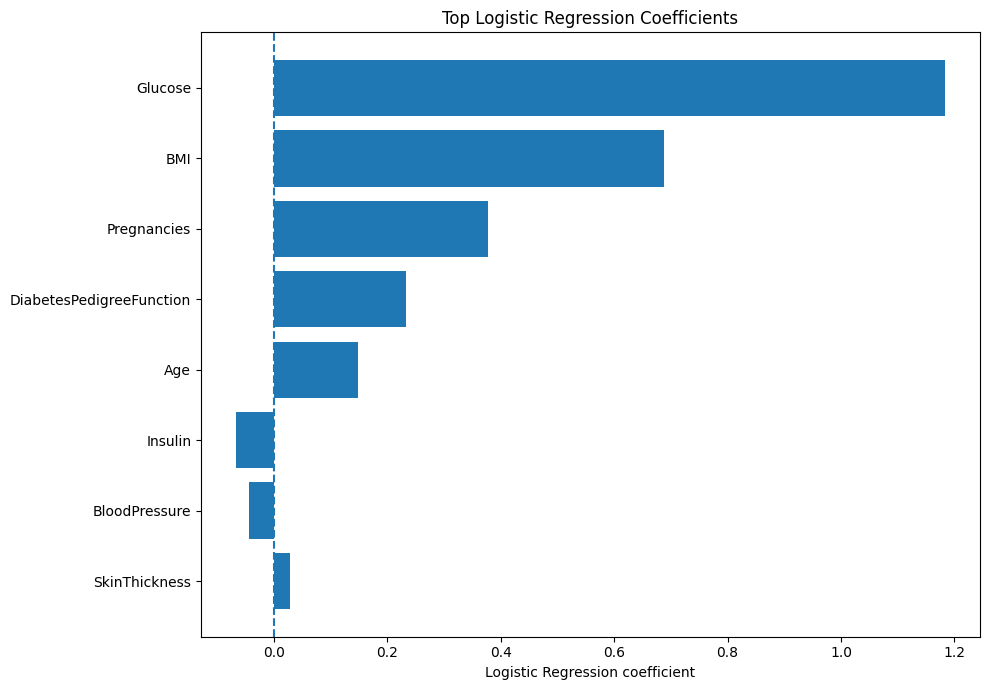

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.182567,1.182567
5,BMI,0.688652,0.688652
0,Pregnancies,0.377446,0.377446
6,DiabetesPedigreeFunction,0.233337,0.233337
7,Age,0.147794,0.147794
4,Insulin,-0.066119,0.066119
2,BloodPressure,-0.044111,0.044111
3,SkinThickness,0.028321,0.028321


In [42]:
# STEP 36 — Logistic Regression coefficients
log_pipe = trained_models["Logistic Regression"]

log_feature_names = log_pipe.named_steps["preprocessor"].get_feature_names_out()
log_coefficients = log_pipe.named_steps["model"].coef_[0]

coef_df = (
    pd.DataFrame({
        "Feature": log_feature_names,
        "Coefficient": log_coefficients,
        "Absolute_Coefficient": np.abs(log_coefficients)
    })
    .sort_values("Absolute_Coefficient", ascending=False)
)

plt.figure(figsize=(10, 7))
top_n = min(15, len(coef_df))

plt.barh(
    coef_df["Feature"].head(top_n)[::-1],
    coef_df["Coefficient"].head(top_n)[::-1]
)

plt.axvline(0, linestyle="--")
plt.xlabel("Logistic Regression coefficient")
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()

display(coef_df.head(15))


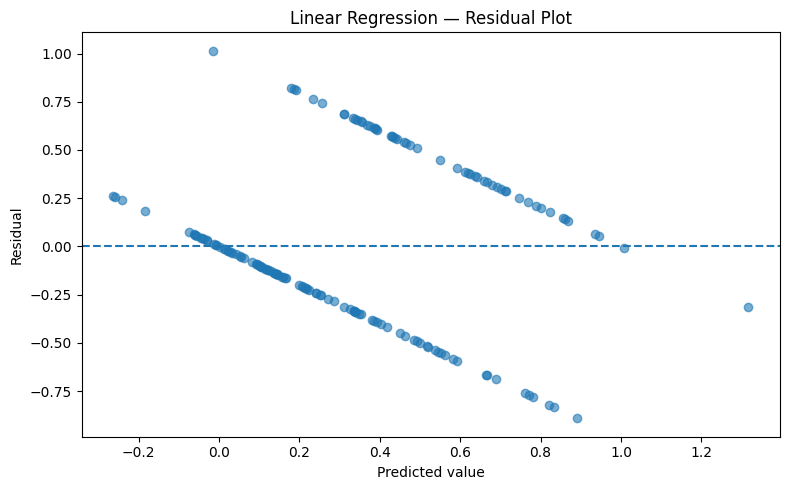

In [43]:
# STEP 37 — Linear Regression predictions and residuals
linear_pipe = trained_models["Linear Regression"]

linear_pred = linear_pipe.predict(X_test)
linear_residuals = y_test.to_numpy() - linear_pred

plt.figure(figsize=(8, 5))
plt.scatter(linear_pred, linear_residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted value")
plt.ylabel("Residual")
plt.title("Linear Regression — Residual Plot")
plt.tight_layout()
plt.show()


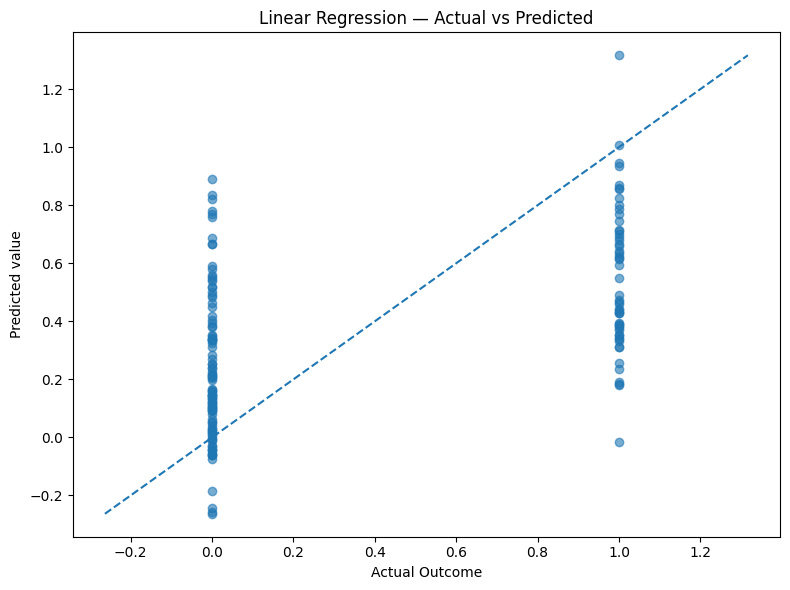

In [44]:
# STEP 38 — Actual vs predicted values for Linear Regression
plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, alpha=0.6)

minimum = min(y_test.min(), linear_pred.min())
maximum = max(y_test.max(), linear_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], "--")
plt.xlabel("Actual Outcome")
plt.ylabel("Predicted value")
plt.title("Linear Regression — Actual vs Predicted")
plt.tight_layout()
plt.show()


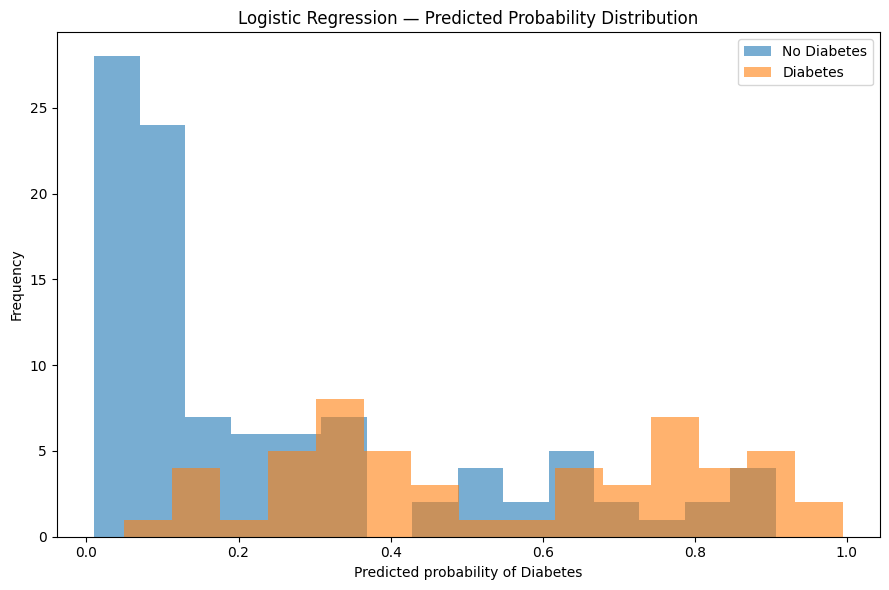

In [45]:
# STEP 39 — Prediction score distributions
plt.figure(figsize=(9, 6))

for outcome_value, label in [(0, "No Diabetes"), (1, "Diabetes")]:
    plt.hist(
        scores["Logistic Regression"][y_test.to_numpy() == outcome_value],
        bins=15,
        alpha=0.6,
        label=label
    )

plt.xlabel("Predicted probability of Diabetes")
plt.ylabel("Frequency")
plt.title("Logistic Regression — Predicted Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()


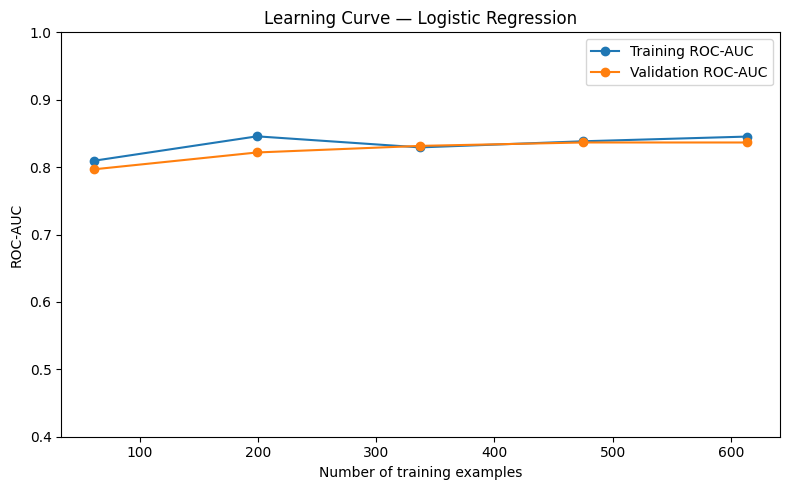

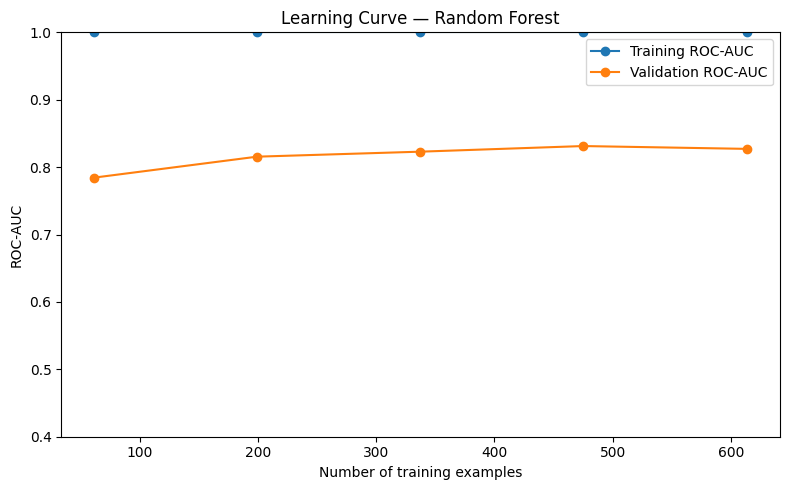

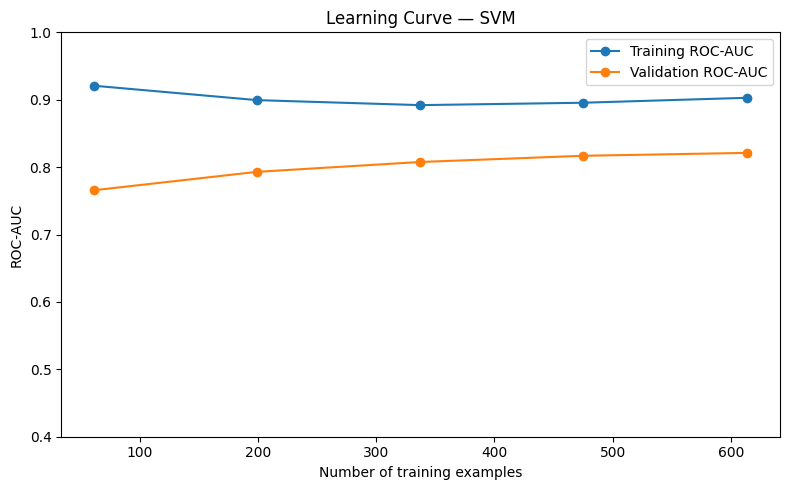

In [46]:
# STEP 40 — Learning curves for the best classification models
# Change this list if you want to inspect different models.
learning_curve_models = [
    "Logistic Regression",
    "Random Forest",
    "SVM"
]

for name in learning_curve_models:
    estimator = models[name]

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    train_sizes, train_scores, validation_scores = learning_curve(
        pipe,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validation ROC-AUC")
    plt.xlabel("Number of training examples")
    plt.ylabel("ROC-AUC")
    plt.ylim(0.4, 1.0)
    plt.title(f"Learning Curve — {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [47]:
# STEP 41 — Final ranking by important metrics
print("🏆 Best model by F1:")
print(
    results_df.sort_values("F1", ascending=False).iloc[0][
        ["Model", "F1", "Accuracy", "Precision", "Recall", "ROC_AUC", "PR_AUC"]
    ]
)

print("\n🏆 Best model by ROC-AUC:")
print(
    results_df.sort_values("ROC_AUC", ascending=False).iloc[0][
        ["Model", "F1", "Accuracy", "Precision", "Recall", "ROC_AUC", "PR_AUC"]
    ]
)

print("\n🏆 Best model by Recall:")
print(
    results_df.sort_values("Recall", ascending=False).iloc[0][
        ["Model", "F1", "Accuracy", "Precision", "Recall", "ROC_AUC", "PR_AUC"]
    ]
)

print("\nComplete test-set comparison:")
display(results_df.round(4))

print("\nCross-validation comparison:")
display(cv_df.round(4))


🏆 Best model by F1:
Model        Decision Tree
F1                0.678261
Accuracy           0.75974
Precision         0.639344
Recall            0.722222
ROC_AUC           0.762222
PR_AUC            0.585402
Name: 0, dtype: object

🏆 Best model by ROC-AUC:
Model        Random Forest
F1                0.591837
Accuracy           0.74026
Precision         0.659091
Recall            0.537037
ROC_AUC           0.816019
PR_AUC            0.698914
Name: 2, dtype: object

🏆 Best model by Recall:
Model        Decision Tree
F1                0.678261
Accuracy           0.75974
Precision         0.639344
Recall            0.722222
ROC_AUC           0.762222
PR_AUC            0.585402
Name: 0, dtype: object

Complete test-set comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MAE,RMSE,R2
0,Decision Tree,0.7597,0.6393,0.7222,0.6783,0.7622,0.5854,NaN,NaN,NaN
1,SVM,0.7403,0.6522,0.5556,0.6000,0.7964,0.6615,NaN,NaN,NaN
2,Random Forest,0.7403,0.6591,0.5370,0.5918,0.8160,0.6989,NaN,NaN,NaN
3,KNN,0.7273,0.6250,0.5556,0.5882,0.7900,0.6391,NaN,NaN,NaN
4,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130,0.6733,NaN,NaN,NaN
5,Linear Regression,0.7013,0.5909,0.4815,0.5306,0.8126,0.6708,0.3344,0.4144,0.2459



Cross-validation comparison:


,Model,CV ROC-AUC Mean,CV ROC-AUC Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Logistic Regression,0.8434,0.0185,0.8669,0.8395,0.8512,0.8485,0.8107
1,SVM,0.8333,0.0228,0.8250,0.8262,0.8741,0.8049,0.8363
2,Random Forest,0.8209,0.0209,0.8382,0.8145,0.8517,0.7964,0.8039
3,KNN,0.7983,0.0329,0.8230,0.7735,0.8506,0.7650,0.7793
4,Decision Tree,0.7706,0.0286,0.8221,0.7407,0.7783,0.7616,0.7503
5,Linear Regression,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
# STEP 42 — Save cleaned data and model-comparison tables
df_model.to_csv("Diabetes_cleaned.csv", index=False)
results_df.to_csv("diabetes_model_comparison_results.csv", index=False)
cv_df.to_csv("diabetes_cross_validation_results.csv", index=False)
importance_df.to_csv("diabetes_random_forest_feature_importance.csv", index=False)
coef_df.to_csv("diabetes_logistic_regression_coefficients.csv", index=False)

print("All output files saved successfully.")


All output files saved successfully.
